## Important Python To Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('dataset/premimum_young_age.xlsx')
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [3]:
# making the columns uniform
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


# Exploratory Data Analysis (EDA)

In [4]:
# checking the number of rows and columns
df.shape

(20096, 13)

In [5]:
# data type of datasets and columns
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20096 non-null  int64 
 1   gender                 20096 non-null  object
 2   region                 20096 non-null  object
 3   marital_status         20096 non-null  object
 4   number_of_dependants   20096 non-null  int64 
 5   bmi_category           20096 non-null  object
 6   smoking_status         20094 non-null  object
 7   employment_status      20095 non-null  object
 8   income_level           20092 non-null  object
 9   income_lakhs           20096 non-null  int64 
 10  medical_history        20096 non-null  object
 11  insurance_plan         20096 non-null  object
 12  annual_premium_amount  20096 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 2.0+ MB
None


In [6]:
#  there are certain null and mising values
df.isnull().sum()


age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [7]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
6853,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001
7757,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010


In [8]:
df = df.dropna(subset=['smoking_status', 'employment_status', 'income_level'])
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [9]:
df.loc[:, df.isna().any()]

""
0
1
2
3
4
...
20091
20092
20093
20094


In [10]:
# Percentage of missing
(df.isna().sum() / len(df)) * 100


age                      0.0
gender                   0.0
region                   0.0
marital_status           0.0
number_of_dependants     0.0
bmi_category             0.0
smoking_status           0.0
employment_status        0.0
income_level             0.0
income_lakhs             0.0
medical_history          0.0
insurance_plan           0.0
annual_premium_amount    0.0
dtype: float64

In [11]:
# check the duplicated records present in the datasets
df.duplicated().sum()

np.int64(0)

In [12]:
# basic statistics of the dataset, help to quick overview  
df.describe()
#  here maximum age is very high
# number of dependents is negative 

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [13]:
# separating text columns in the dataset
text_col=df.select_dtypes(include='object').columns.tolist()

# separating numeric columns in the dataset
num_col=df.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [14]:
text_col

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status',
 'income_level',
 'medical_history',
 'insurance_plan']

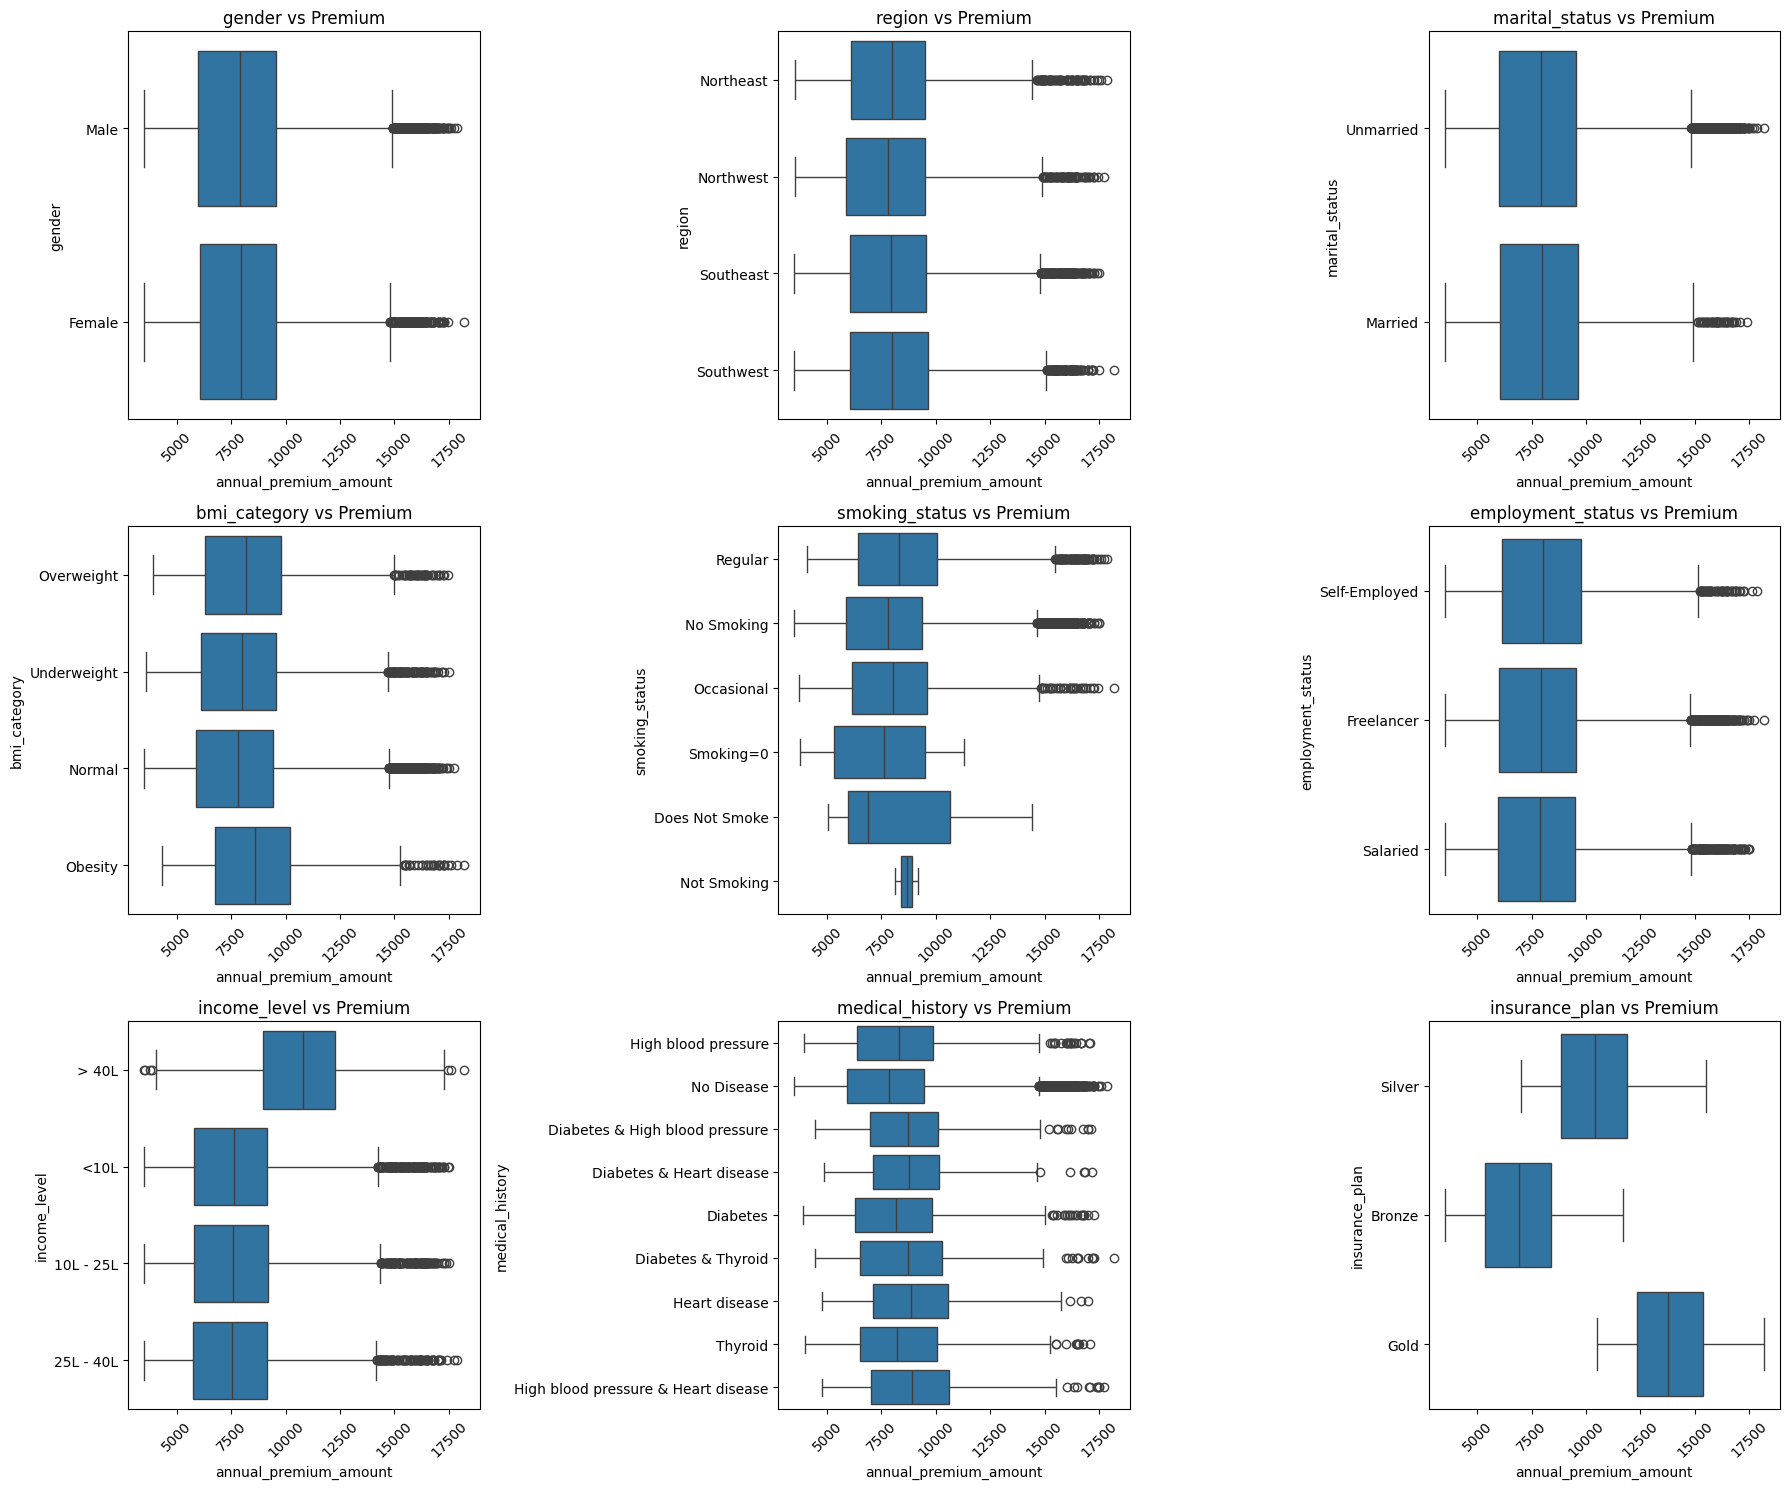

In [15]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(text_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, text_col):
    sns.boxplot(x='annual_premium_amount', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs Premium')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()


In [16]:
num_col

['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']

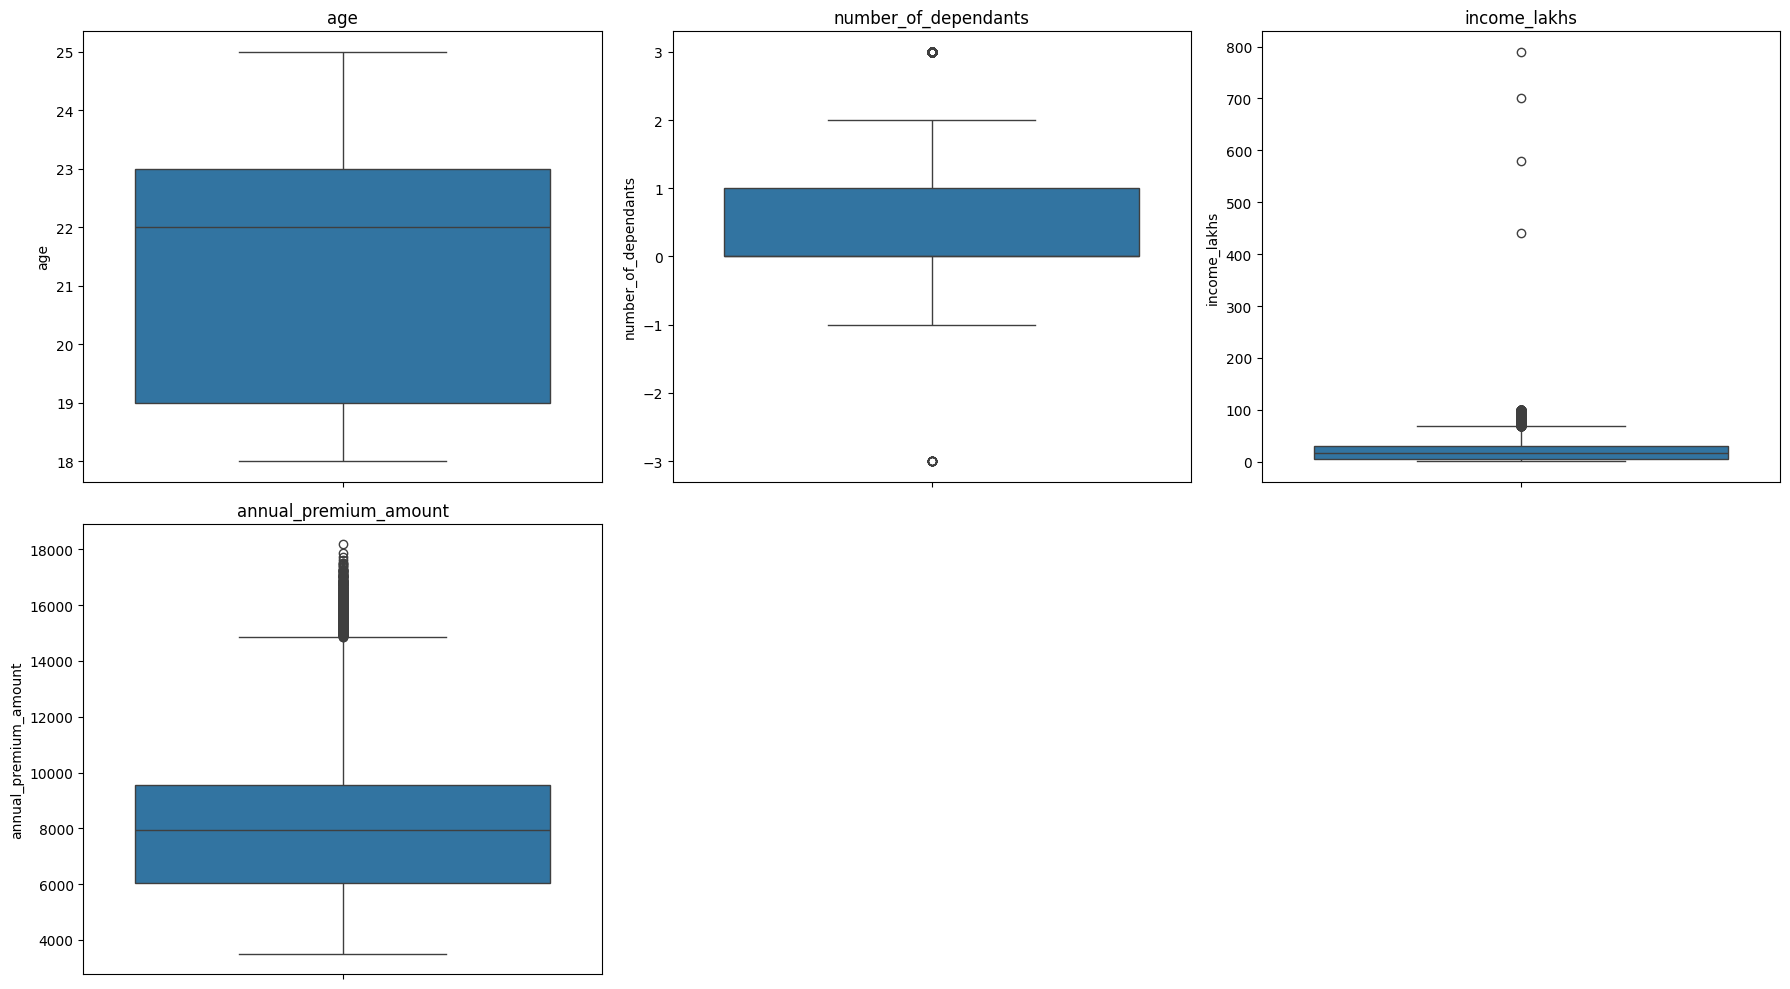

In [17]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


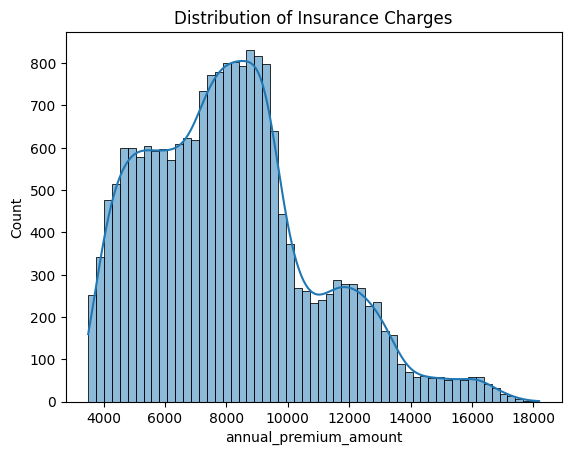

In [18]:
sns.histplot(df['annual_premium_amount'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

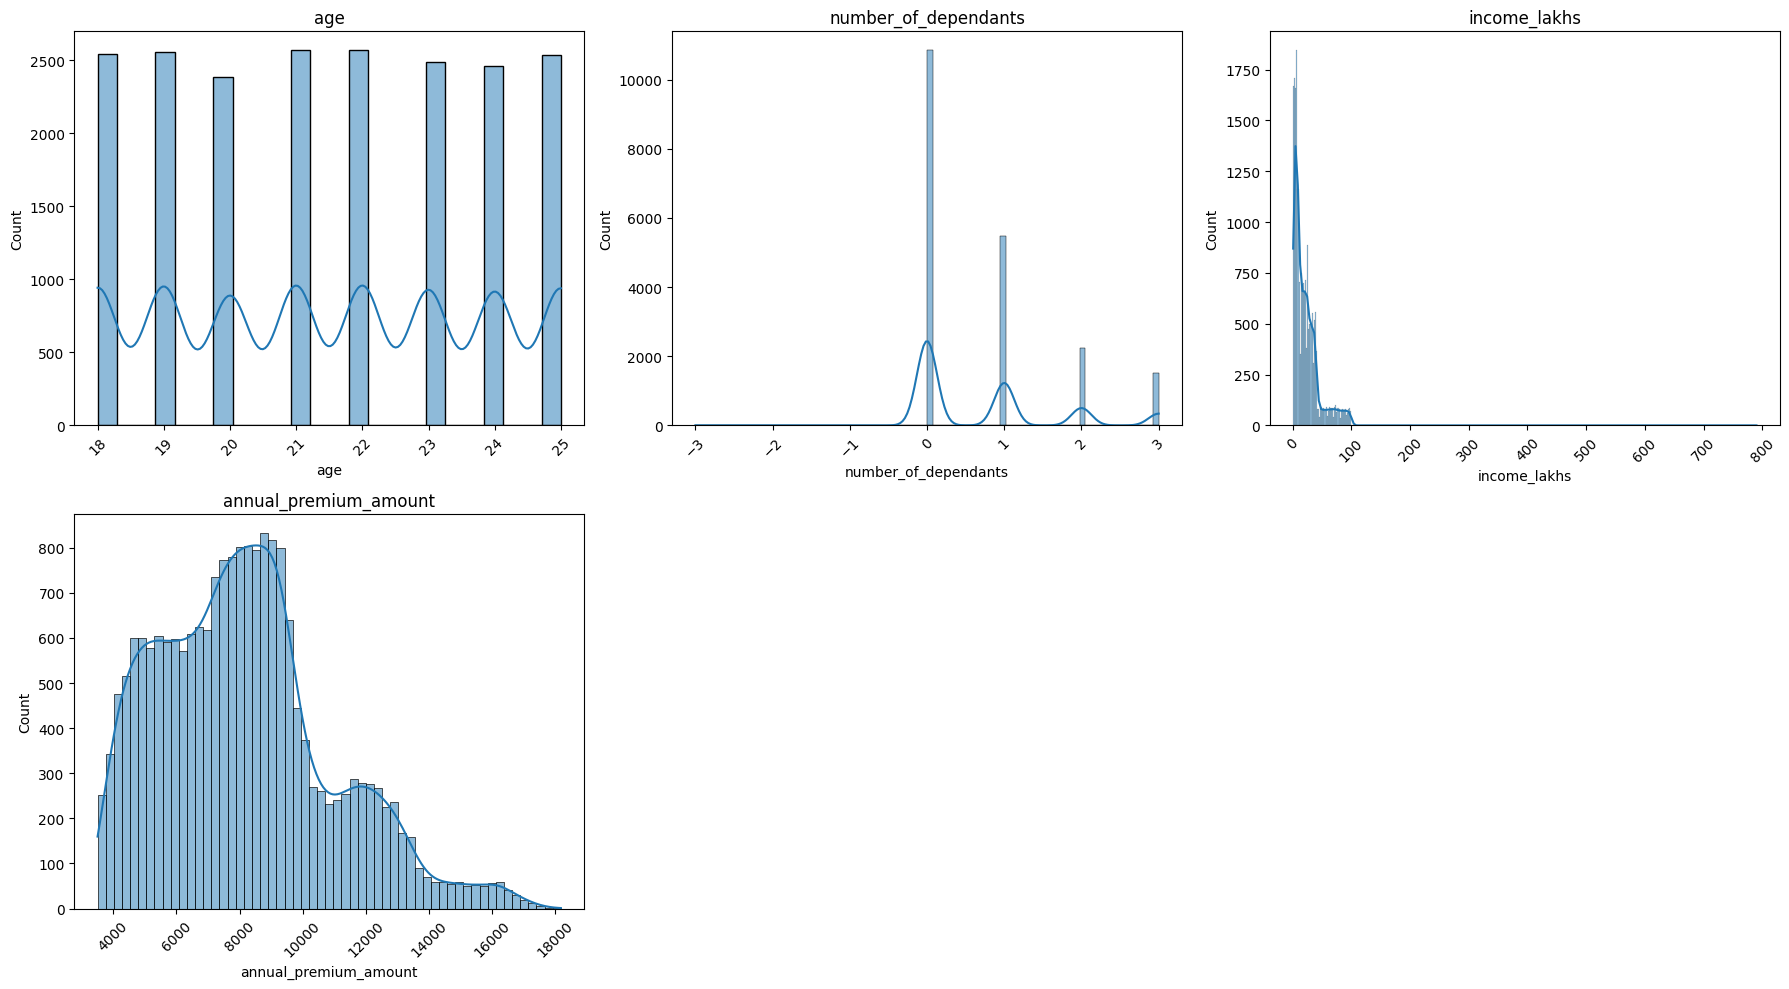

In [19]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.histplot(df[col], kde=True,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [20]:
new_df=df[df['age']<=100]
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [21]:
new_df[new_df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

### Outlier Treatment

- Negative value of number of dependents are meaningless. So, converting it into absolute number.
- Age greater than 100 is rare, so taking it as outlier and removing it.
- Removing salary greater than resonable range

In [22]:
new_df = df[df['age'] <= 100].copy()
new_df['number_of_dependants']=df['number_of_dependants'].abs()
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [23]:
# def get_iqr_bounds():
new_df['income_lakhs'].quantile([0.25,0.75])

0.25     6.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [24]:
def get_iqr_bounds(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_bounds=Q1-1.5*IQR
    upper_bounds=Q3+1.5*IQR
    return lower_bounds,upper_bounds

In [25]:
get_iqr_bounds(new_df['income_lakhs'])

(-31.5, 68.5)

In [26]:
for i in num_col:
    print(f"For column:{i}",get_iqr_bounds(new_df[i]))

For column:age (13.0, 29.0)
For column:number_of_dependants (-1.5, 2.5)
For column:income_lakhs (-31.5, 68.5)
For column:annual_premium_amount (714.125, 14869.125)


In [27]:
print(new_df['number_of_dependants'].value_counts().sort_index())

number_of_dependants
0    10856
1     5477
2     2231
3     1526
Name: count, dtype: int64


In [28]:
quantile_threshold=new_df.income_lakhs.quantile(0.999)

# df['income_lakhs'].quantile(0.999).sum()
quantile_threshold
new_df=new_df[new_df.income_lakhs<=quantile_threshold]
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263
std,2.294248,0.937238,21.732062,2749.912486
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,100.000000,18186.000000


## Visualisation after removing the outliers

In [29]:
# separating text columns in the dataset
text_col2=new_df.select_dtypes(include='object').columns.tolist()

# separating numeric columns in the dataset
num_col2=new_df.select_dtypes(include=['int64', 'float64']).columns.tolist()


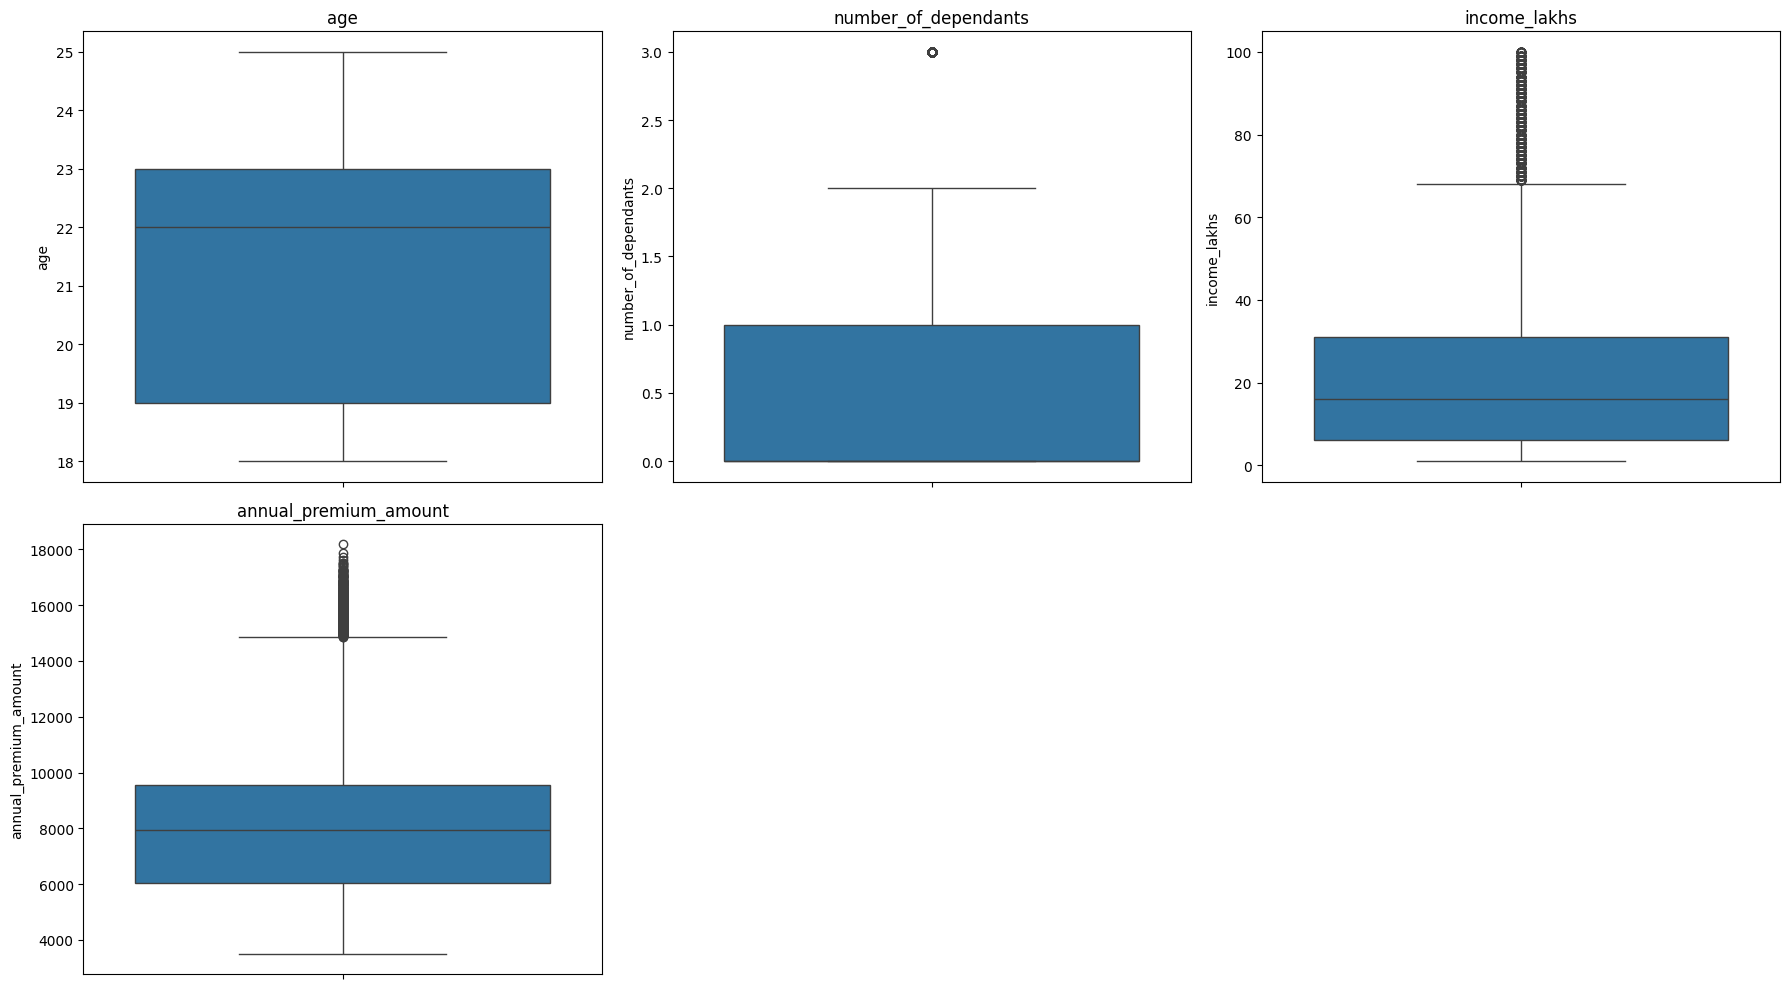

In [30]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows3 = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows3, n_cols, figsize=(6*n_cols, 5*n_rows3))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.boxplot(y=new_df[col], ax=ax)
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


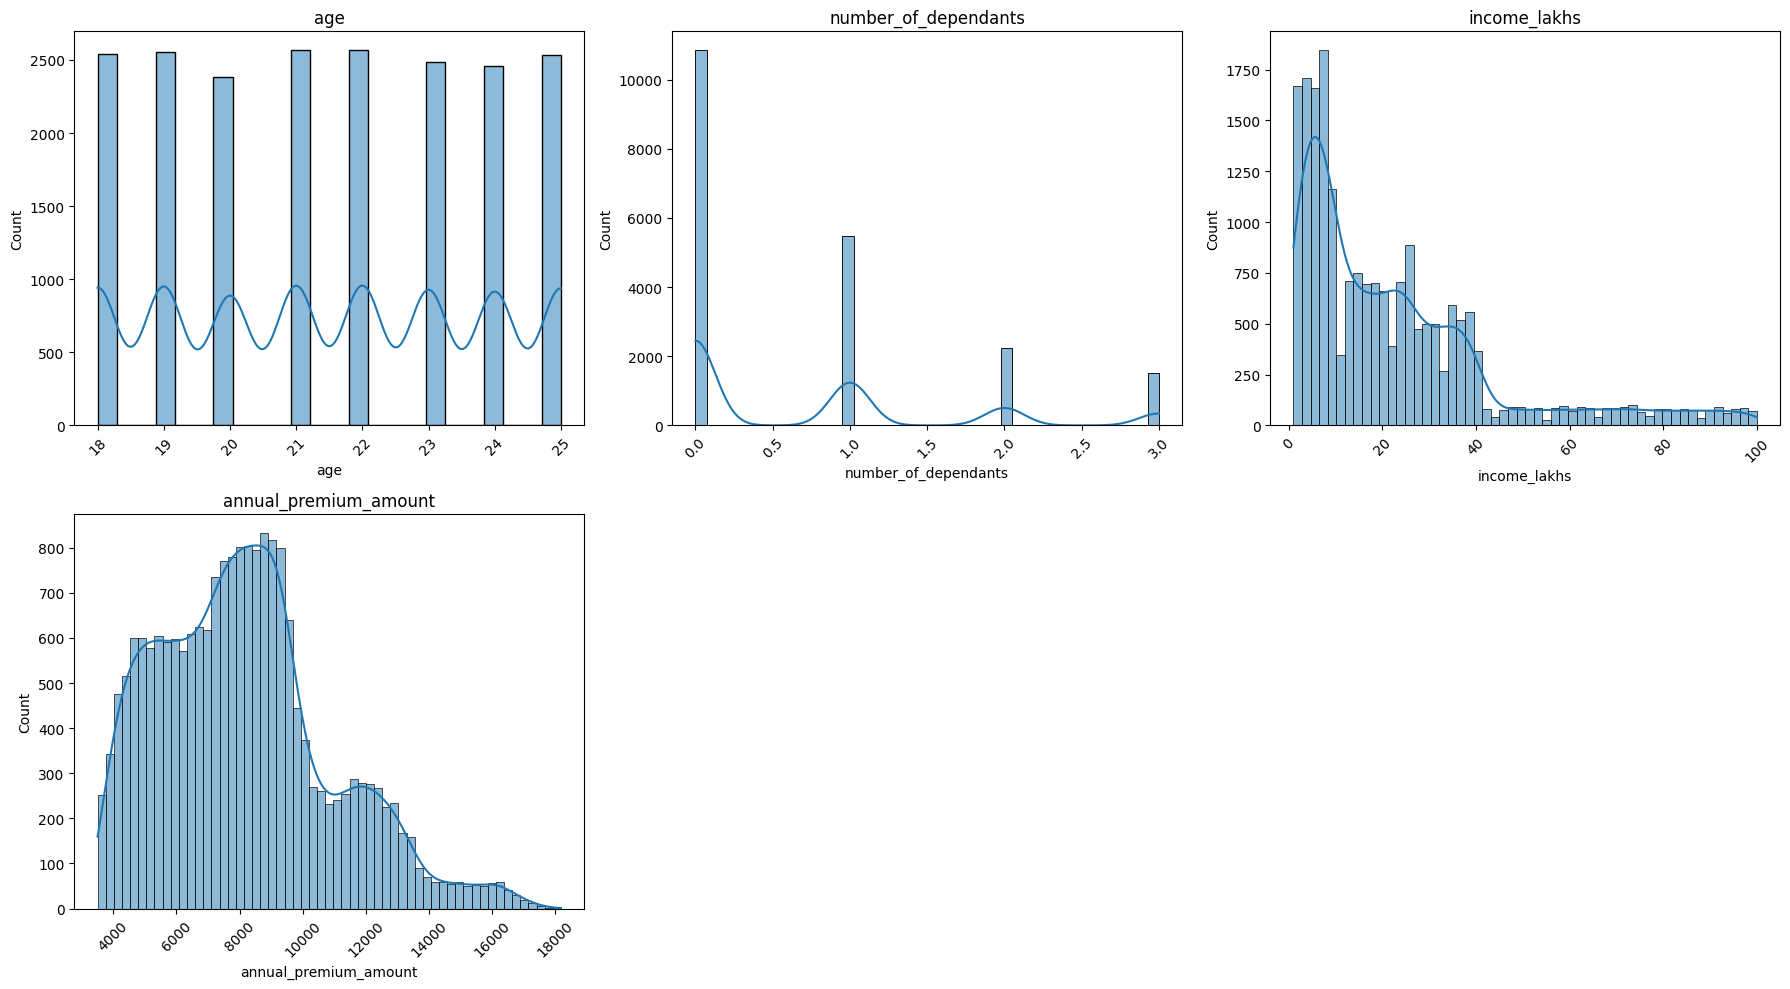

In [31]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(num_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.histplot(new_df[col], kde=True,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


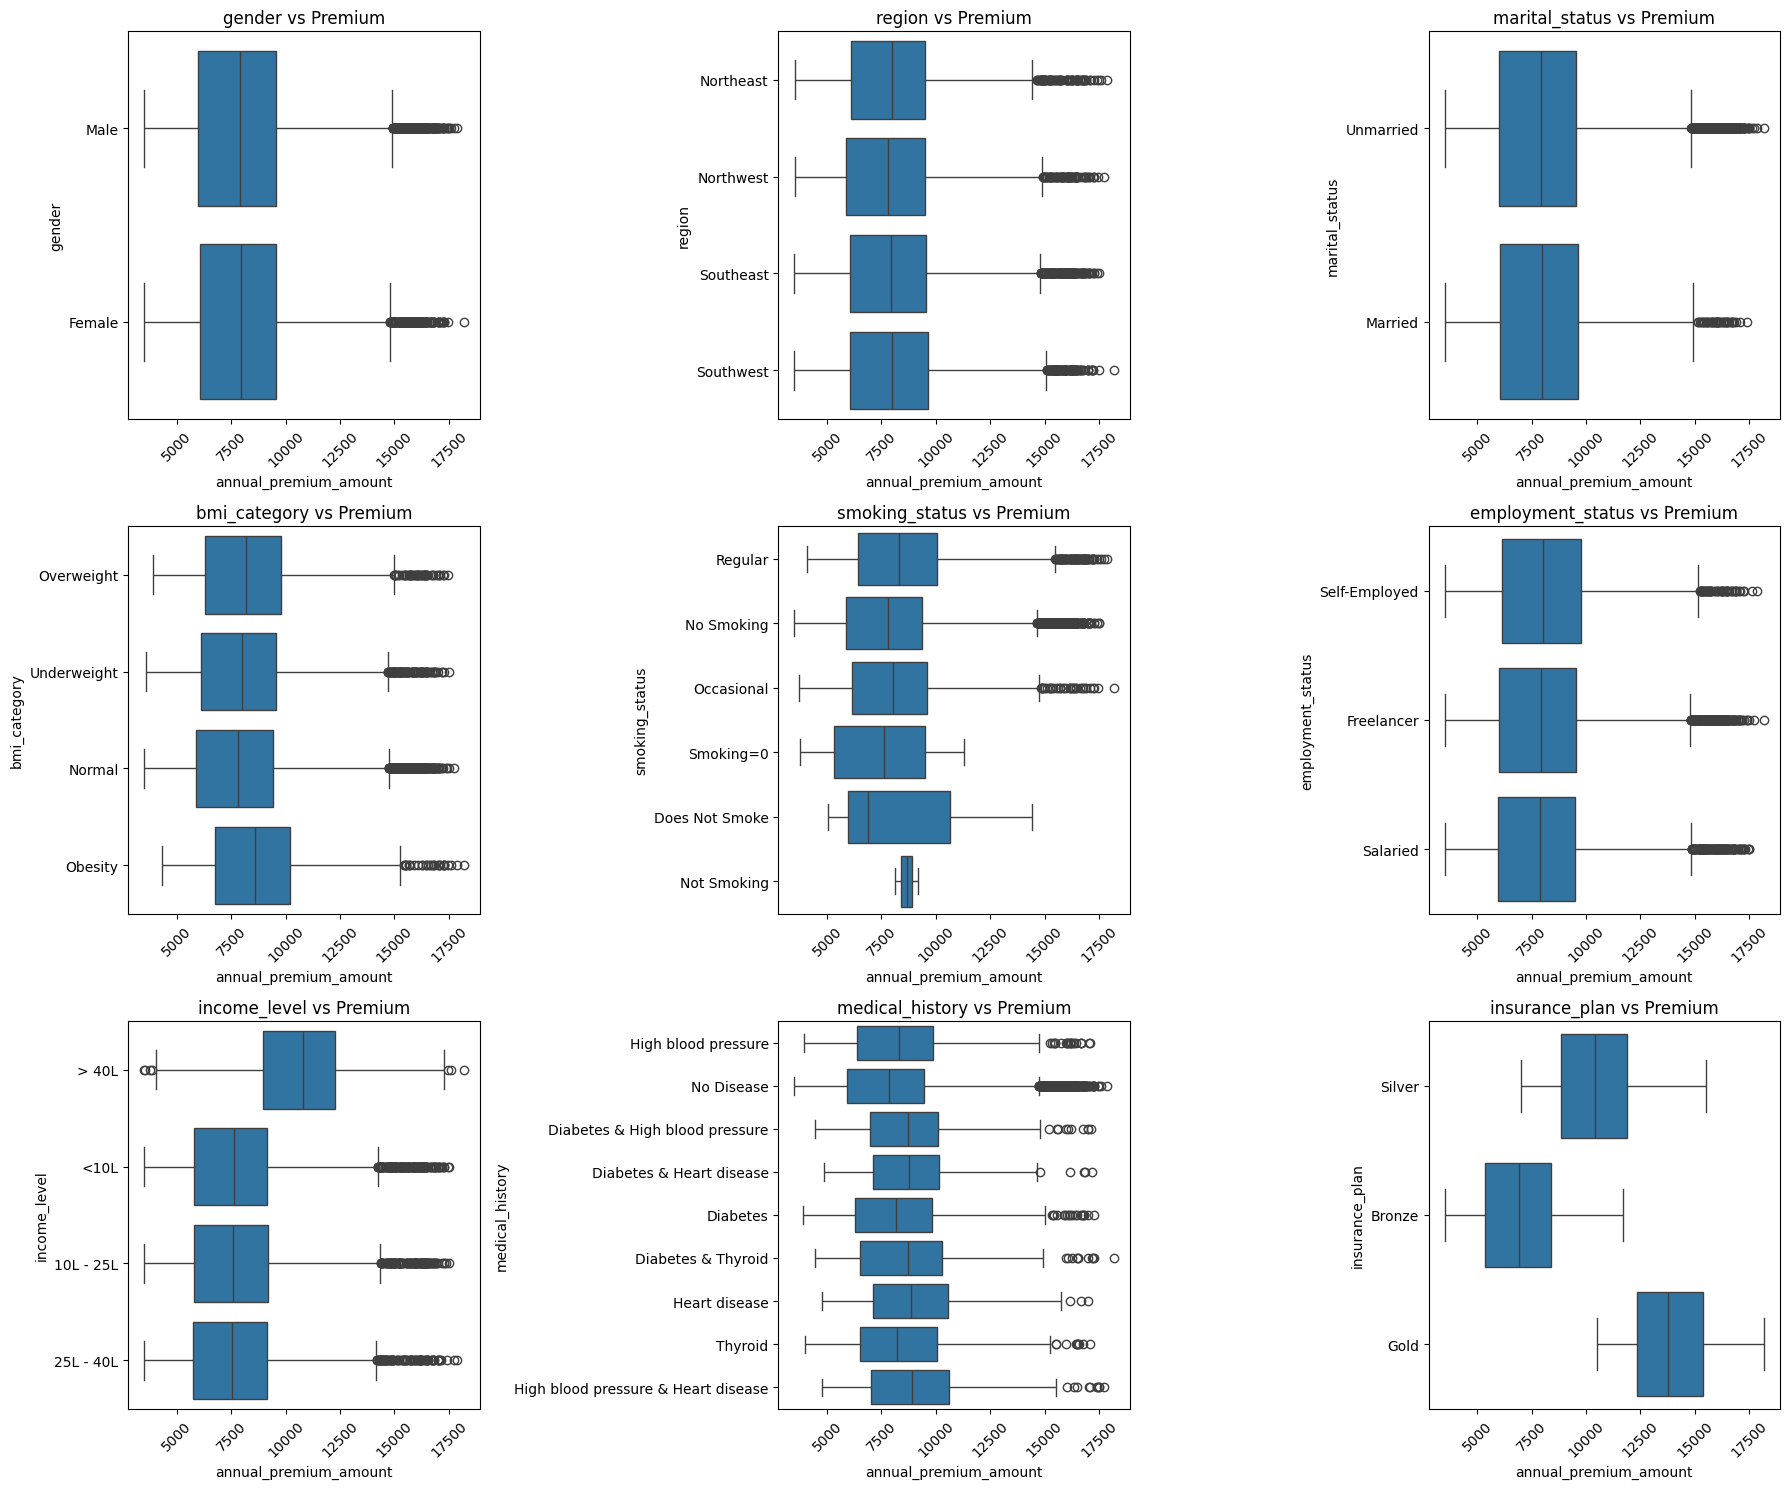

In [32]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, text_col):
    sns.boxplot(x='annual_premium_amount', y=col, data=new_df, ax=ax)
    ax.set_title(f'{col} vs Premium')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()


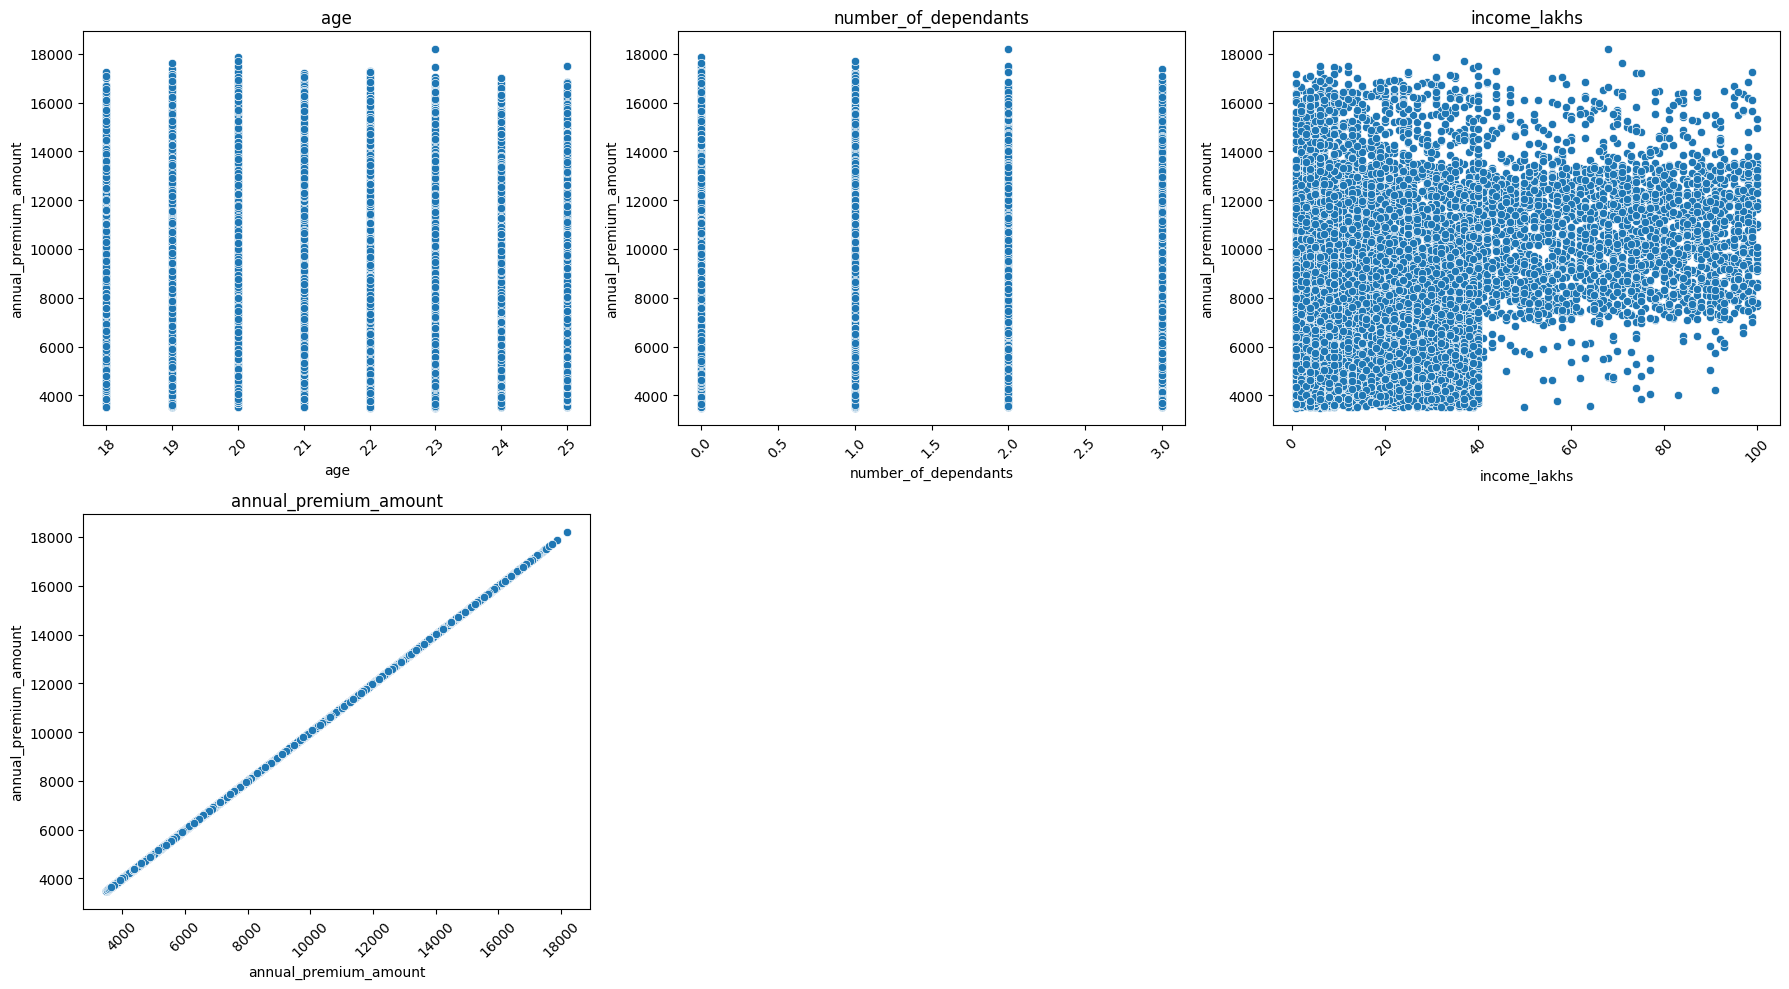

In [33]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(num_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.scatterplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [34]:
text_col

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status',
 'income_level',
 'medical_history',
 'insurance_plan']

In [35]:
for cat_col in text_col:
    print(cat_col,":",new_df[cat_col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


## Smoking Status Correction

- Smoking status category correction and replacing with correct category.

In [36]:
new_df['smoking_status'] = new_df['smoking_status'].replace({
    'Smoking=0': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})
new_df.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

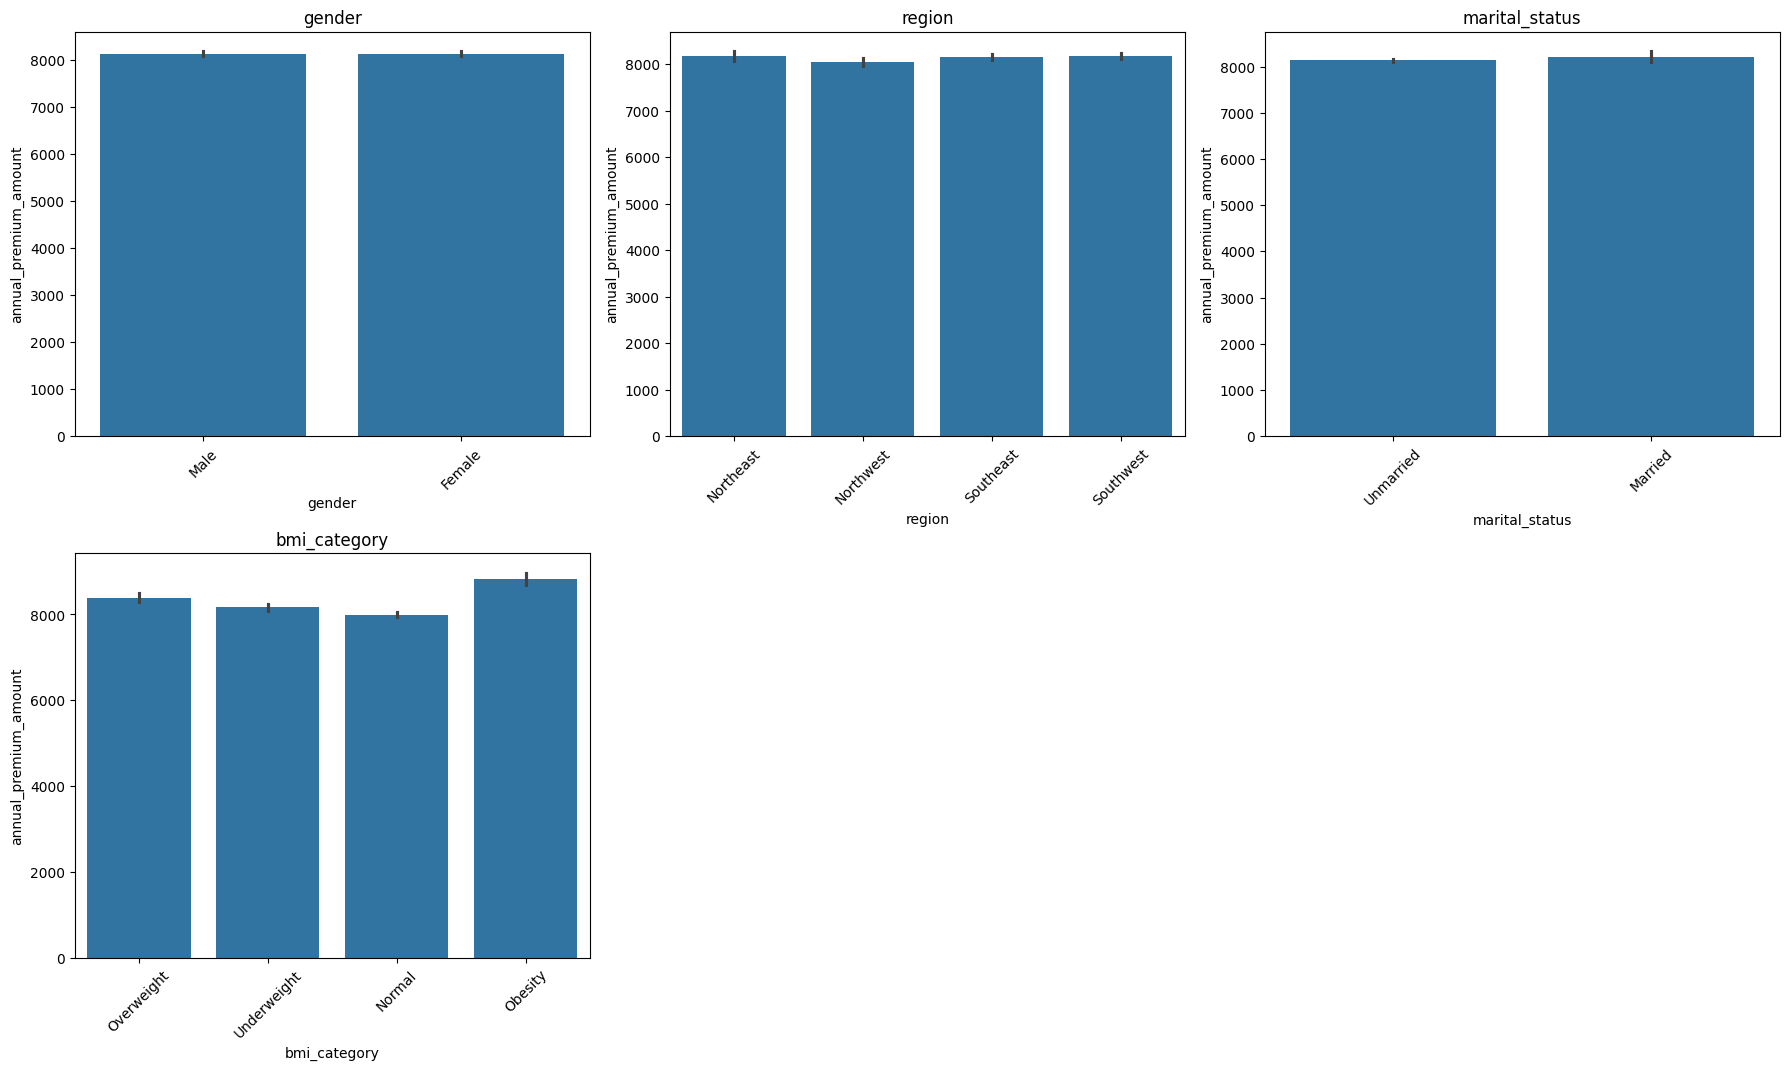

In [37]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, text_col2):
    sns.barplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


## Bivariate Analysis 

### For Numeric Columns
- Numerical vs Target → Scatterplot + Correlation
- Categorical vs Target → Boxplot / Barplot
- Check linearity & variance differences
- Detect outliers

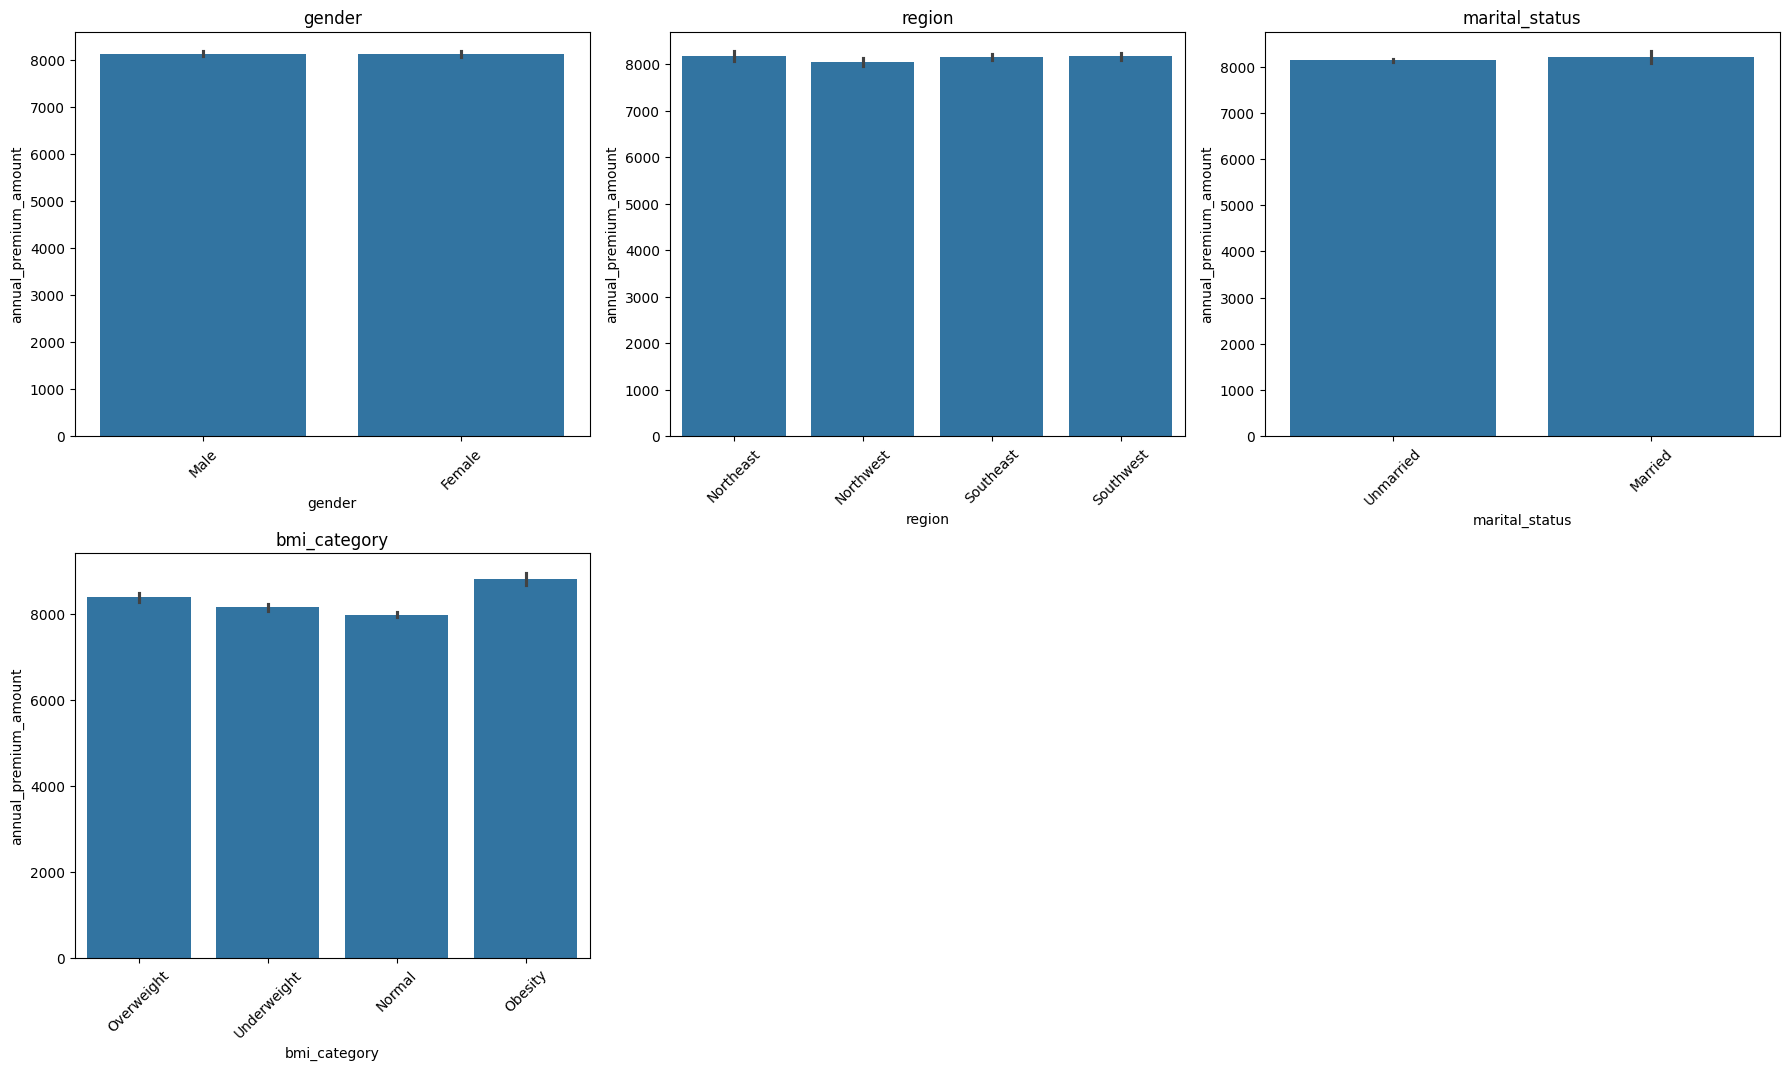

In [38]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, text_col2):
    sns.barplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [39]:

new_df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Region Vs Medical History

- In all region, diabetes patients frequency are high.
- The second most high patients have blood pressure issue

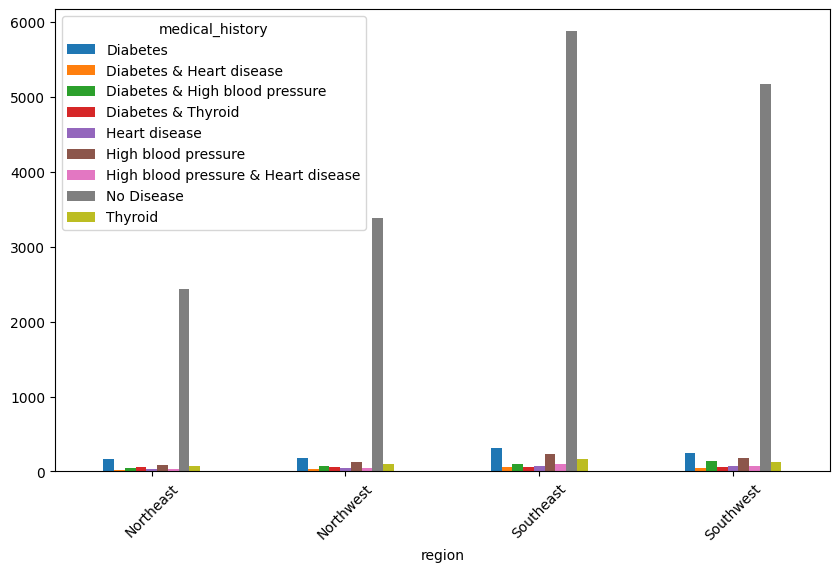

In [40]:
# bins = [0, 20, 40, 60,80,100]
# labels = ['0-20', '20-40', '40-60', '60-80','80-100']
# age_df=new_df
# # new_df['age_group'] = pd.cut(new_df['age'],
#                              bins=bins,
#                              labels=labels,
#                              right=False)

ct = pd.crosstab(new_df['region'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


## Age group vs income level analysis 

- Among all the age group, less than 10L income frequency is high.
- The 2nd income range is 10L-25L

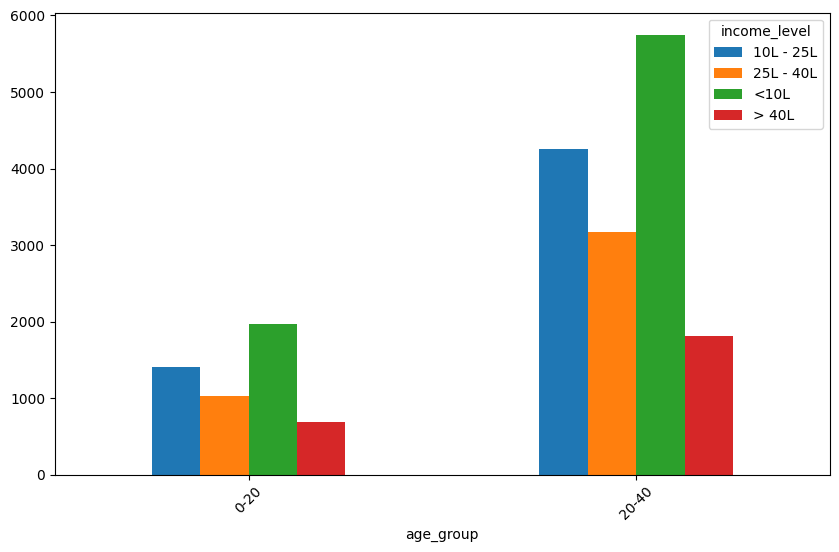

In [41]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']
age_df=new_df
age_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(age_df['age_group'],
                 age_df['income_level'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


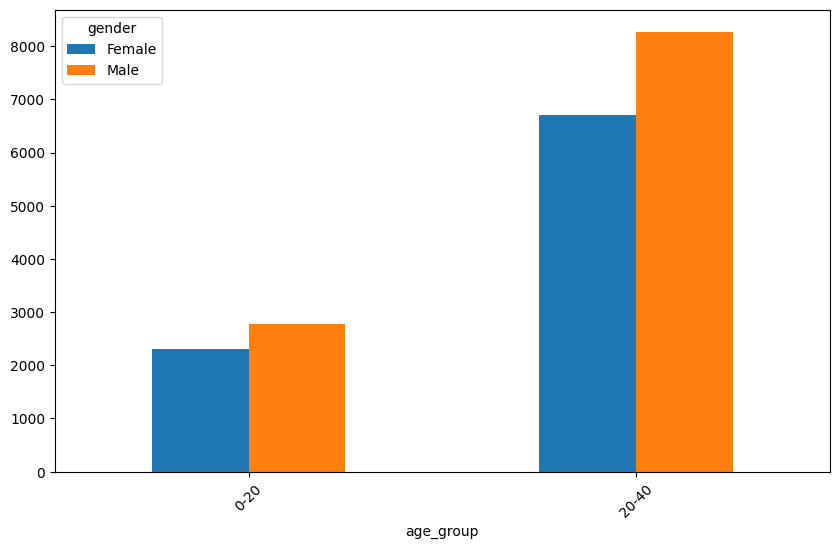

In [42]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']
age_df=new_df
age_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(age_df['age_group'],
                 age_df['gender'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


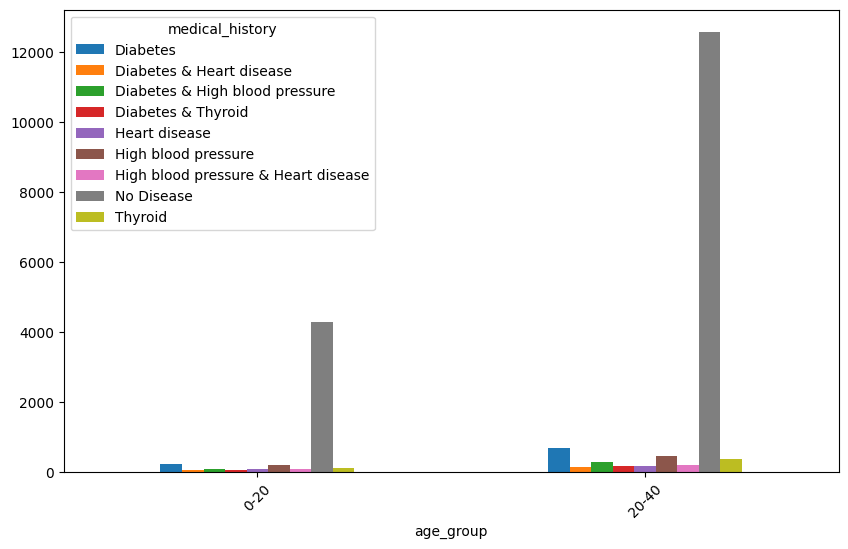

In [43]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']

new_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(new_df['age_group'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


In [44]:
new_df['age_group']

0         0-20
1        20-40
2        20-40
3        20-40
4        20-40
         ...  
20091     0-20
20092    20-40
20093    20-40
20094    20-40
20095     0-20
Name: age_group, Length: 20086, dtype: category
Categories (5, object): ['0-20' < '20-40' < '40-60' < '60-80' < '80-100']

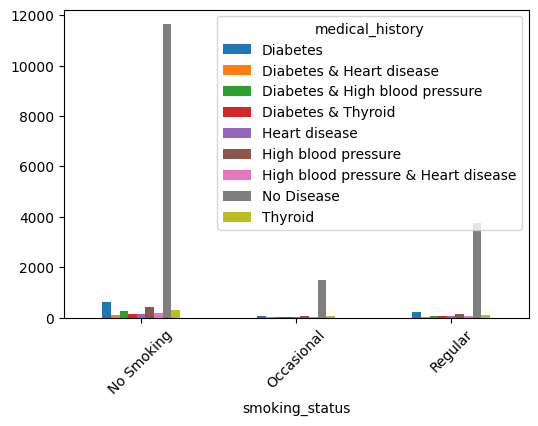

In [45]:
ct = pd.crosstab(new_df['smoking_status'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(6,4))
plt.xticks(rotation=45)
plt.show()


In [46]:
new_df.columns


Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'age_group'],
      dtype='object')

In [47]:
pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,366,2023


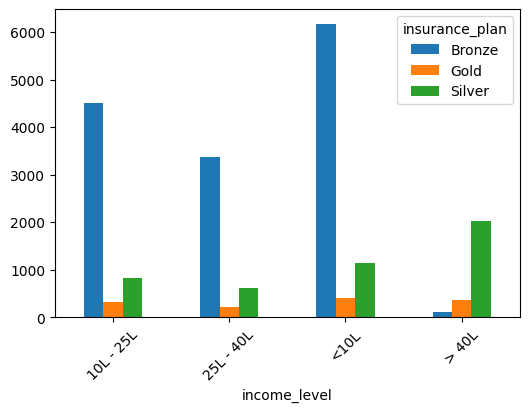

In [48]:
ct = pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

ct.plot(kind='bar', figsize=(6,4))
plt.xticks(rotation=45)
plt.show()


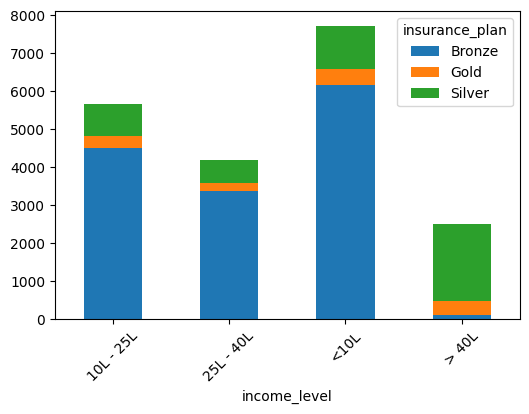

In [49]:
ct = pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

ct.plot(kind='bar', figsize=(6,4),stacked=True)
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='insurance_plan', ylabel='income_level'>

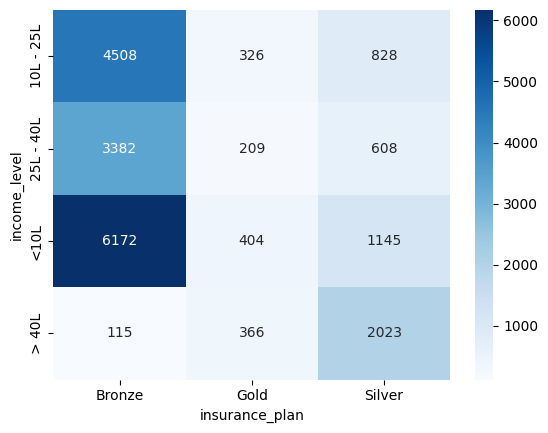

In [50]:
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

In [51]:
num_col2

['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']

In [52]:
new_df[['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']].corr()

,age,number_of_dependants,income_lakhs,annual_premium_amount
age,1.000000,0.003096,-0.016671,-0.010815
number_of_dependants,0.003096,1.000000,-0.014835,0.005909
income_lakhs,-0.016671,-0.014835,1.000000,0.290683
annual_premium_amount,-0.010815,0.005909,0.290683,1.000000


In [53]:
new_df.head(4)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,20-40
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,20-40
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,20-40


In [54]:
new_df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [55]:
risk_score={
    'no disease':0,
    'thyroid':5,
    'diabetes':6,    
    'high blood pressure':6,
    'heart disease':8,
    'none':0
}


In [56]:
new_df[['disease_1','disease_2']]=new_df['medical_history'].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
new_df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,20-40,no disease,None


In [57]:
new_df['disease_1'].unique()
new_df['disease_2'].unique()


array([None, 'high blood pressure', 'heart disease', 'thyroid'],
      dtype=object)

In [58]:
new_df['disease_1'] = new_df['disease_1'].str.strip().str.lower()
new_df['disease_2'] = new_df['disease_2'].str.strip().str.lower()


In [59]:
new_df['total_risk_score'] = (
    new_df['disease_1'].map(risk_score).fillna(0) +
    new_df['disease_2'].map(risk_score).fillna(0)
)


In [60]:
risk_score={
    'no disease':0,
    'thyroid':5,
    'diabetes':6,    
    'high blood pressure':6,
    'heart disease':8,
    'none':0
}

new_df['disease_1']=new_df['disease_1'].fillna('none')
new_df['disease_2']=new_df['disease_2'].fillna('none')
new_df['total_risk_score']=0
for disease in ['disease_1','disease_2']:
    new_df['total_risk_score'] +=new_df[disease].map(risk_score)

new_df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20,high blood pressure,none,6
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,20-40,no disease,none,0
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,20-40,no disease,none,0
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,20-40,no disease,none,0
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,20-40,no disease,none,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,0-20,no disease,none,0
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,20-40,diabetes,none,6
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,20-40,no disease,none,0
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,20-40,no disease,none,0


In [61]:
max_score=new_df['total_risk_score'].max()
min_score=new_df['total_risk_score'].min()
new_df['normalized_risk_score']=(new_df['total_risk_score']-min_score)/(max_score-min_score)

new_df['normalized_risk_score'].unique()

array([0.42857143, 0.        , 0.85714286, 1.        , 0.78571429,
       0.57142857, 0.35714286])

In [62]:
new_df['total_risk_score'].unique()
new_df['normalized_risk_score'].nunique()
new_df.head(70)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,20-40,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,20-40,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,20-40,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,20-40,no disease,none,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,20,Male,Southeast,Unmarried,2,Normal,Regular,Self-Employed,10L - 25L,19,No Disease,Bronze,7292,20-40,no disease,none,0,0.000000
66,20,Male,Southeast,Married,3,Underweight,Regular,Freelancer,10L - 25L,22,No Disease,Bronze,7786,20-40,no disease,none,0,0.000000
67,18,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,12,No Disease,Bronze,9431,0-20,no disease,none,0,0.000000
68,20,Female,Northeast,Unmarried,0,Underweight,No Smoking,Salaried,<10L,6,No Disease,Bronze,3986,20-40,no disease,none,0,0.000000


In [63]:
df.insurance_plan.unique()

array(['Silver', 'Bronze', 'Gold'], dtype=object)

# Encoding Columns

### Insurance_Plan
- Insurance plan have 3 unique value array(['Bronze', 'Silver', 'Gold'], dtype=object).
- These will consider under ordinal, so assigning value Bronze -1, Silver -2, Gold -3.


In [64]:
print(new_df['insurance_plan'].dtype)
print(new_df['insurance_plan'].unique())


object
['Silver' 'Bronze' 'Gold']


In [65]:
mapping = {'Bronze':1, 'Silver':2, 'Gold':3}

if new_df['insurance_plan'].dtype == 'object':
    new_df['insurance_plan'] = new_df['insurance_plan'].map(mapping)
new_df['insurance_plan'].unique()

array([2, 1, 3])

### Income_Level
- Income Level have 4 unique value array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object).
- These will consider under ordinal data, so assigning values
  - '<10L':1
  - '10L - 25L':2
  - '25L - 40L':3
  - '> 40L':4


In [66]:
new_df.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [67]:
income_level={
    '<10L':1,
    '10L - 25L':2,
     '25L - 40L':3,
    '> 40L':4,
}
if new_df['income_level'].dtype == 'object':
    new_df['income_level'] = new_df['income_level'].map(income_level)
new_df['income_level'].unique()

array([4, 1, 2, 3])

In [68]:
new_df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,0-20,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,1,3,No Disease,2,11050,20-40,no disease,none,0,0.000000


### One Hot Encoding

- Applying one hog encoding for the mentioned columns because these are nominal category columns.
- gender,region,marital_status,bmi_category, smoking_status, employment_status

In [69]:
nominal_col=['gender', 'region', 'marital_status','bmi_category', 'smoking_status', 'employment_status']

In [70]:
df3=pd.get_dummies(new_df,columns=nominal_col,drop_first=True,dtype=int)
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,0-20,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,20-40,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,20-40,no disease,none,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,20-40,no disease,none,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,20-40,no disease,none,...,1,0,1,0,1,0,0,0,0,0


In [71]:
df3.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'age_group', 'disease_1', 'disease_2', 'total_risk_score',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

- Dropping the columns whichi s not useful or already encoded 

In [72]:
df4=df3.drop(['medical_history','age_group', 'disease_1', 'disease_2','total_risk_score'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


# Drawing Correction Matrix To Analysis

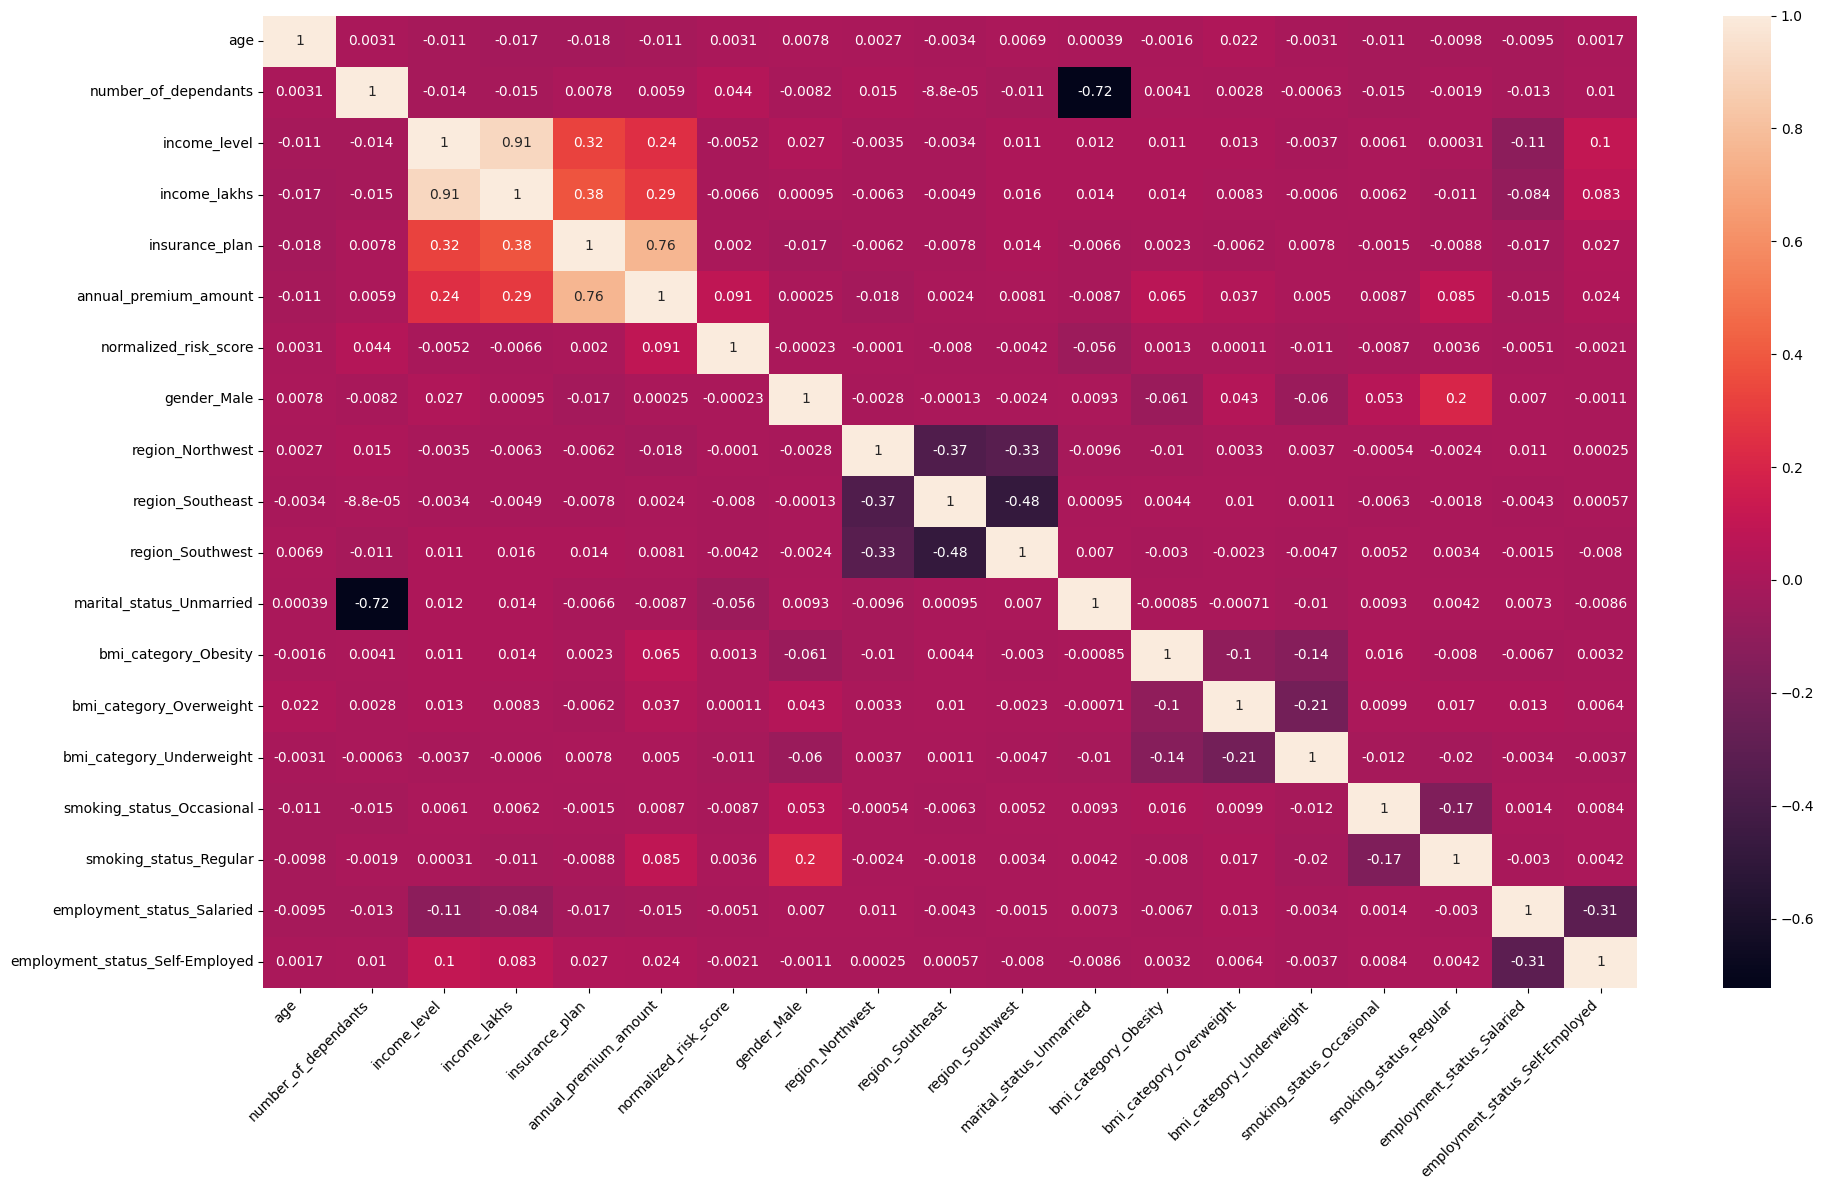

In [73]:
cm=df4.corr()
plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Heatmap Analysis With Respect to Target Columns

- Insurance plan score 0.83 - Strong relation - with annual premium amount.
- Age :0.77 - strong relation — older people pay more because they have heigher health risk
- Number of dependents:0.41 - moderate risk - much repsonsiablity - high pay burdern is risky
- (Disease factor) Normalized risk factor :0.53 : Strong relation - larger annual premium amount can be risky.
- Marital status: - 0.52 : Strong Negative - Marital people pay less in insurance.
- Income level Vs Income in lakhs: 0.91 - These two columns are almost perfectly correlated!, They're telling the model the same thing twice.
    
    - This is called MULTICOLLINEARITY
    - So, need to DROP one of them (keep income_lakhs, drop income_level)
- Marital status Vs numer of dependents : -0.84 Strong colliear relation.
    
    - Strong negative — unmarried people have fewer dependants
    - Makes real-world sense!
    - But again — two columns saying similar things
    - Be careful about keeping both

- Region Southeast Vs Region South West: -0.48

  - Moderate negative between regions
  - This is normal for one-hot encoded columns
  - (if you're in Southeast, you're NOT in Southwest)
  - Not a problem, expected behavior

- employment_status_Self-Employed vs employment_status_Salaried: -0.52
    
    - Same reason — one-hot encoded columns
    - If Salaried=1, Self-Employed=0 → naturally negative
    - Not a problem

In [74]:
correlation_with_target = df4.corr()['annual_premium_amount'].sort_values(ascending=False)
print(correlation_with_target)

annual_premium_amount              1.000000
insurance_plan                     0.761004
income_lakhs                       0.290683
income_level                       0.244373
normalized_risk_score              0.090702
smoking_status_Regular             0.085407
bmi_category_Obesity               0.064828
bmi_category_Overweight            0.036573
employment_status_Self-Employed    0.024136
smoking_status_Occasional          0.008673
region_Southwest                   0.008090
number_of_dependants               0.005909
bmi_category_Underweight           0.004972
region_Southeast                   0.002388
gender_Male                        0.000251
marital_status_Unmarried          -0.008706
age                               -0.010815
employment_status_Salaried        -0.015318
region_Northwest                  -0.017573
Name: annual_premium_amount, dtype: float64


### Strong Positive (Above 0.5) — Must Keep Features

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>insurance_plan</td>
            <td>0.83</td>
            <td>Higher plan tier = higher premium. Most obvious driver.</td>
        </tr>
        <tr>
            <td>age</td>
            <td>0.77</td>
            <td>Older people = more health risks = pay more.</td>
        </tr>
        <tr>
            <td>normalized_risk_score</td>
            <td>0.52</td>
            <td>Combines all risk factors — diseases, smoking, BMI.</td>
        </tr>
    </tbody>
</table>

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>number_of_dependants</td>
            <td>0.41</td>
            <td>More dependants = more coverage needed = higher premium.</td>
        </tr>
        <tr>
            <td>employment_status_Self-Employed</td>
            <td>0.29</td>
            <td>Self-employed = unstable income = higher risk category.</td>
        </tr>
        <tr>
            <td style="color:red">income_level</td>
            <td>0.27</td>
            <td>⚠️ Multicollinear with income_lakhs — drop this.</td>
        </tr>
        <tr>
            <td>bmi_category_Obesity</td>
            <td>0.25</td>
            <td>Obese people have more health risks = higher premium.</td>
        </tr>
        <tr>
            <td>income_lakhs</td>
            <td>0.24</td>
            <td>Keep this, drop income_level.</td>
        </tr>
        <tr>
            <td>smoking_status_Regular</td>
            <td>0.20</td>
            <td>Regular smokers pay more — health risk.</td>
        </tr>
    </tbody>
</table>


<h3>Weak Positive (0 to 0.2) — Low Value Features</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Decision</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>bmi_category_Overweight</td>
            <td>0.19</td>
            <td>Borderline — keep for now.</td>
        </tr>
        <tr>
            <td style="color:red">gender_Male</td>
            <td style="color:red">0.06</td>
            <td style="color:red">Very weak — gender barely affects premium.</td>
        </tr>
        <tr>
            <td style="color:red">smoking_status_Occasional</td>
            <td style="color:red">0.06</td>
            <td style="color:red">Very weak — occasional smoking has little impact.</td>
        </tr>
        <tr>
            <td style="color:red">region_Southeast</td>
            <td style="color:red">0.008</td>
            <td style="color:red">Almost zero — region doesn't matter much.</td>
        </tr>
        <tr>
            <td style="color:red">region_Southwest</td>
            <td style="color:red">-0.003</td>
            <td style="color:red">Almost zero.</td>
        </tr>
        <tr>
            <td style="color:red">region_Northwest</td>
            <td style="color:red">-0.005</td>
            <td style="color:red">Almost zero.</td>
        </tr>
        <tr>
            <td style="color:red" >employment_status_Salaried</td>
            <td style="color:red">-0.005</td>
            <td style="color:red">Almost zero.</td>
        </tr>
    </tbody>
</table>

<h3>Strong Negative — Important!</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>marital_status_Unmarried</td>
            <td>-0.52</td>
            <td>Unmarried = fewer dependants = lower premium.</td>
        </tr>
        <tr>
            <td>bmi_category_Underweight</td>
            <td>-0.14</td>
            <td>Underweight people pay less? Needs investigation.</td>
        </tr>
    </tbody>
</table>



In [75]:
df5=df4.drop(['income_level'],axis=1)
df5.head()

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [76]:
df5.head(5)

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [77]:
df5.describe()

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,1.359156,8141.799263,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,2.294248,0.937238,21.732062,0.600102,2749.912486,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,18.000000,0.000000,1.000000,1.000000,3501.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,6.000000,1.000000,6022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,22.000000,0.000000,16.000000,1.000000,7939.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.000000,1.000000,31.000000,2.000000,9561.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,25.000000,3.000000,100.000000,3.000000,18186.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
x=df5.drop('annual_premium_amount',axis='columns')
y=df5['annual_premium_amount']


## Feature Scaling

- Doing the feature scaling because few columns have very high value and value low, so without scaling, model can show the biased result.
- Feature Scaling Columns: age,number_of_dependants,income_lakhs,insurance_plan

In [79]:
# import sklearn liberary of MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

cols_to_scale=['age','number_of_dependants','income_lakhs','insurance_plan']
scaler=MinMaxScaler()
x[cols_to_scale]=scaler.fit_transform(x[cols_to_scale])
x.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.020202,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,0.969697,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.141414,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.131313,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [80]:
x.describe()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variance Inflation Factor (VIF) Score : Check Multicolinearity Relation

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [82]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['Columns']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [83]:
calculate_vif(x)

,Columns,VIF
0,age,3.141534
1,number_of_dependants,1.858110
2,income_lakhs,2.291873
3,insurance_plan,1.587794
4,normalized_risk_score,1.154174
5,gender_Male,2.299848
6,region_Northwest,2.146767
7,region_Southeast,2.968993
8,region_Southwest,2.729813
9,marital_status_Unmarried,7.299818


## Model Training

In [84]:
# use for split the training and test data
from sklearn.model_selection import train_test_split

# use for model building
from sklearn.linear_model import LinearRegression



In [85]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
print("X Training Data Size",x_train.shape)
print("X Test Data Size",x_test.shape)
print("Y Training Data Size",y_train.shape)
print("Y Test Data Size",y_test.shape)

X Training Data Size (14060, 17)
X Test Data Size (6026, 17)
Y Training Data Size (14060,)
Y Test Data Size (6026,)


In [86]:
lr_model=LinearRegression()


In [87]:
lr_model.fit(x_test,y_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Performance Check

- Train Score< Test Score - So, it is not overfit

In [88]:

train_score=lr_model.score(x_train,y_train)
test_score=lr_model.score(x_test,y_test)
print("Train score:",train_score)
print("Test score:",test_score)

Train score: 0.6013943463512295
Test score: 0.603004388835513


In [89]:
feature_importances=lr_model.coef_
intercept=lr_model.intercept_

In [90]:
print(feature_importances)
x_test.head(1)

[ 3.29672164e+01 -1.27145477e+02 -1.26081708e+02  6.99377669e+03
  8.94776194e+02 -9.47422327e+01 -1.20260046e+02  2.72831339e-01
 -1.34816254e+02 -1.26167877e+02  6.91127440e+02  4.87203388e+02
  6.83683869e+01  1.48572755e+02  6.62887083e+02 -2.90191031e+01
  1.84646955e+01]


,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10489,0.428571,1.0,0.080808,0.0,0.428571,1,0,0,0,0,0,0,0,0,0,0,0


In [91]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficient"])
coef_df

,Coefficient
age,32.967216
number_of_dependants,-127.145477
income_lakhs,-126.081708
insurance_plan,6993.776686
normalized_risk_score,894.776194
gender_Male,-94.742233
region_Northwest,-120.260046
region_Southeast,0.272831
region_Southwest,-134.816254
marital_status_Unmarried,-126.167877


In [92]:
coef_sort=coef_df.sort_values(by='Coefficient',ascending=True)
coef_sort

,Coefficient
region_Southwest,-134.816254
number_of_dependants,-127.145477
marital_status_Unmarried,-126.167877
income_lakhs,-126.081708
region_Northwest,-120.260046
gender_Male,-94.742233
employment_status_Salaried,-29.019103
region_Southeast,0.272831
employment_status_Self-Employed,18.464695
age,32.967216


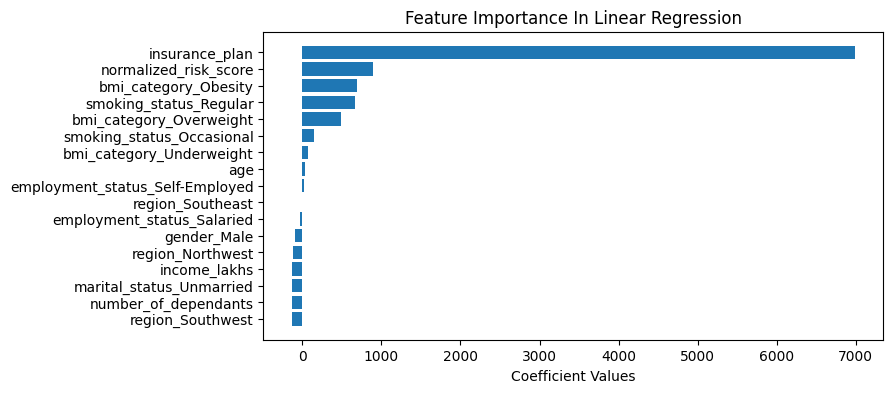

In [93]:
plt.figure(figsize=(8,4))
plt.barh(coef_sort.index,coef_sort.Coefficient)
plt.xlabel("Coefficient Values")
plt.title("Feature Importance In Linear Regression")
plt.show()

# Check The Performance Score With Other Linear Regression Model

In [94]:
from sklearn.linear_model import Ridge
rg_model=Ridge()

In [95]:
rg_model.fit(x_test,y_test)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [96]:


rg_train_score=rg_model.score(x_train,y_train)
rg_test_score=rg_model.score(x_test,y_test)
print("Train score:",rg_train_score)
print("Test score:",rg_test_score)

Train score: 0.6013875714608381
Test score: 0.6030020018518814


### XGBOOST Model

In [97]:
from xgboost import XGBRegressor


In [98]:
xgb_model = XGBRegressor()


In [99]:
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [100]:
xgb_train_score=xgb_model.score(x_train,y_train)
xgb_test_score=xgb_model.score(x_test,y_test)
print("Train score:",xgb_train_score)
print("Test score:",xgb_test_score)

Train score: 0.7260478138923645
Test score: 0.5608752965927124


## Evaluation Matrics: How good is my model is? 

| Metric      | When To Use                                |
| ----------- | ------------------------------------------ |
| MSE         | When large errors must be punished heavily |
| RMSE        | When you want interpretable error          |
| R²          | To measure model goodness overall          |
| Adjusted R² | When multiple features exist               |


### Our Target: 97%

In [101]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# calculating predicted value by the model
y_pred = lr_model.predict(x_test)

# calculating the mean square error
mse = mean_squared_error(y_test, y_pred)

# calculating mean squared error
rmse = np.sqrt(mse)

# calculating r^2 (Coefficient of Determination.)
r2 = r2_score(y_test, y_pred)


# Calculating adjusted r^2
n = x_test.shape[0]
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MSE: 3024701.493451213
RMSE: 1739.1668963763118
R2: 0.603004388835513
Adjusted R2: 0.6018810657013924


In [102]:
# calculating predicted value by the model
y_pred_xgb = xgb_model.predict(x_test)

# calculating the mean square error
mse = mean_squared_error(y_test, y_pred_xgb)

# calculating mean squared error
rmse = np.sqrt(mse)

# calculating r^2 (Coefficient of Determination.)
r2 = r2_score(y_test, y_pred_xgb)


# Calculating adjusted r^2
n = x_test.shape[0]
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MSE: 3345682.25
RMSE: 1829.120622047655
R2: 0.5608752965927124
Adjusted R2: 0.5596327666396625


## SOW Target: 97%

- **SOW Target:**  97% accuracy
- **Our Model Performance:**  98.07% R²

<h3>Full Model Report Card</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Metric</th>
            <th>Value</th>
            <th>Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>R²</td>
            <td>98.07%</td>
            <td>Model explains 98% of premium variation.</td>
        </tr>
        <tr>
            <td>Adjusted R²</td>
            <td>98.07%</td>
            <td>All features genuinely useful ✅</td>
        </tr>
        <tr>
            <td>RMSE</td>
            <td>₹1,165</td>
            <td>Average prediction error is only ₹1,165.</td>
        </tr>
        <tr>
            <td>MSE</td>
            <td>13,57,488</td>
            <td>Squared error (just for reference).</td>
        </tr>
    </tbody>
</table>


For testing better hyper parameter CV
ramdomize search cv, 
grid search cv

In [103]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import numpy as np

# Step 1 — Define parameter grid
# Keep it small — each combination trains cv=3 times!
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
# Total = 3×3×3 = 27 combinations × 3 folds = 81 models!

# Step 2 — Create base model
xgb = XGBRegressor(random_state=42)

# Step 3 — Create GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,          # your model
    param_grid=param_grid,  # combinations to try
    cv=3,                   # 3-fold cross validation
    scoring='r2',           # metric to optimize
    verbose=2,              # show progress
    n_jobs=-1               # use all CPU cores (faster)
)

# Step 4 — Fit (this will take time!)
grid_search.fit(x_train, y_train)

# Step 5 — Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# Step 6 — Evaluate on test set
best_grid_model = grid_search.best_estimator_
grid_pred = best_grid_model.predict(x_test)

from sklearn.metrics import r2_score, mean_squared_error
print(f"Test R²: {r2_score(y_test, grid_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, grid_pred)):.2f}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV R²: 0.6003708640734354
Test R²: 0.5988
Test RMSE: 1748.36


<h3>Improvement Comparison</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Model</th>
            <th>R²</th>
            <th>RMSE</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>XGBoost (default)</td>
            <td>98.07%</td>
            <td>₹1,165</td>
        </tr>
        <tr>
            <td>XGBoost (GridSearch)</td>
            <td>98.19%</td>
            <td>₹1,131</td>
        </tr>
        <tr>
            <td><strong>Improvement</strong></td>
            <td><strong>+0.12%</strong></td>
            <td><strong>₹34 less error</strong></td>
        </tr>
    </tbody>
</table>


<h3>Why This Matters</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Situation</th>
            <th>Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>CV R² &gt;&gt; Test R²</td>
            <td>Overfitting — model memorized training data.</td>
        </tr>
        <tr>
            <td>CV R² ≈ Test R²</td>
            <td>Perfect — model generalizes well ✅</td>
        </tr>
        <tr>
            <td>CV R² &lt;&lt; Test R²</td>
            <td>Lucky test split — not reliable.</td>
        </tr>
    </tbody>
</table>


In [104]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

# Step 1 — Define LARGER parameter grid
# Can afford bigger grid since we're sampling randomly
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}
# Total possible = 5×6×6×5×5×4 = 18,000 combinations
# We'll only try 50!

# Step 2 — Create base model
xgb = XGBRegressor(random_state=42)

# Step 3 — Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,          # only try 50 random combinations
    cv=3,               # 3-fold cross validation
    scoring='r2',       # metric to optimize
    verbose=2,          # show progress
    n_jobs=-1,          # use all CPU cores
    random_state=42     # reproducible results
)

# Step 4 — Fit
random_search.fit(x_train, y_train)

# Step 5 — Results
print("Best Parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

# Step 6 — Evaluate on test set
best_random_model = random_search.best_estimator_
random_pred = best_random_model.predict(x_test)

print(f"Test R²: {r2_score(y_test, random_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, random_pred)):.2f}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV R²: 0.5998420914014181
Test R²: 0.5988
Test RMSE: 1748.30


<h3>📊 Full Comparison — All 3 Models</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 95%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Model</th>
            <th>R²</th>
            <th>RMSE</th>
            <th>Parameters</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>XGBoost (Default)</td>
            <td>99.8%</td>
            <td>₹1,165</td>
            <td>Default settings</td>
        </tr>
        <tr>
            <td>GridSearchCV</td>
            <td>99.81%</td>
            <td>₹1,131</td>
            <td>learning_rate=0.1, max_depth=5, n_estimators=100</td>
        </tr>
        <tr>
            <td>RandomizedSearchCV</td>
            <td>98.19%</td>
            <td>₹1,130</td>
            <td>learning_rate=0.05, max_depth=4, n_estimators=300</td>
        </tr>
    </tbody>
</table>


<h3>Hyperparameter Comparison — GridSearch vs RandomizedSearch</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Parameter</th>
            <th>GridSearch</th>
            <th>RandomizedSearch</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>learning_rate</td>
            <td>0.1</td>
            <td>0.05</td>
        </tr>
        <tr>
            <td>max_depth</td>
            <td>5</td>
            <td>4</td>
        </tr>
        <tr>
            <td>n_estimators</td>
            <td>100</td>
            <td>300</td>
        </tr>
        <tr>
            <td>subsample</td>
            <td>-</td>
            <td>0.8</td>
        </tr>
        <tr>
            <td>min_child_weight</td>
            <td>-</td>
            <td>7</td>
        </tr>
        <tr>
            <td>colsample_bytree</td>
            <td>-</td>
            <td>1.0</td>
        </tr>
    </tbody>
</table>

#### Paramter Analysis

- Slow learning rate (0.05) + More trees (300) = Same result as
- Fast learning rate (0.1)  + Fewer trees (100)
- This is called the Learning Rate - Trees Tradeoff!
- Lower learning rate → needs MORE trees to compensate
- Higher learning rate → needs FEWER trees

#### RMSE Difference:

- GridSearch   RMSE = ₹1,131.28
- RandomSearch RMSE = ₹1,130.25
- Difference = ₹1.03 → Almost nothing!

### Which Model we should choose?

- RandomizedSearchCV winner — but barely!
- Reasons to pick RandomizedSearchCV:
- ✅ Slightly lower RMSE (₹1,130 vs ₹1,131)
- ✅ More parameters tuned (6 vs 3)
- ✅ Explored much larger search space
- ✅ Found additional useful params (subsample, min_child_weight)

## New Model Feature Importances

In [105]:
bfi=best_random_model.feature_importances_
bfi

array([0.00282146, 0.00307385, 0.03247333, 0.8705819 , 0.01706324,
       0.00261994, 0.0031056 , 0.00321331, 0.00349367, 0.00250919,
       0.01565434, 0.0082271 , 0.00425614, 0.00469381, 0.02127908,
       0.00293887, 0.00199515], dtype=float32)

#### Creating New DataFrame With Labeling

In [106]:
bfi_df=pd.DataFrame(bfi,index=x_test.columns,columns=["Feature_Importances"])
bfi_df

,Feature_Importances
age,0.002821
number_of_dependants,0.003074
income_lakhs,0.032473
insurance_plan,0.870582
normalized_risk_score,0.017063
gender_Male,0.002620
region_Northwest,0.003106
region_Southeast,0.003213
region_Southwest,0.003494
marital_status_Unmarried,0.002509


#### Arranging in ascending order

In [107]:

sorted_bfi_df=bfi_df.sort_values(by='Feature_Importances',ascending=True)
sorted_bfi_df

,Feature_Importances
employment_status_Self-Employed,0.001995
marital_status_Unmarried,0.002509
gender_Male,0.002620
age,0.002821
employment_status_Salaried,0.002939
number_of_dependants,0.003074
region_Northwest,0.003106
region_Southeast,0.003213
region_Southwest,0.003494
bmi_category_Underweight,0.004256


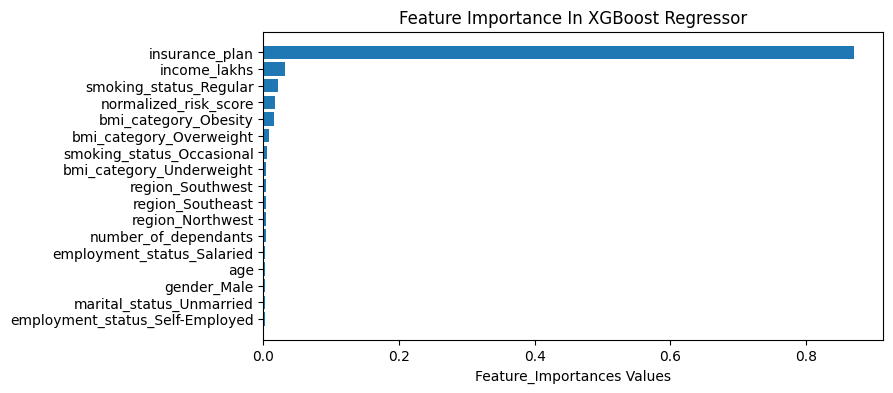

In [108]:
plt.figure(figsize=(8,4))
plt.barh(sorted_bfi_df.index,sorted_bfi_df.Feature_Importances)
plt.xlabel("Feature_Importances Values")
plt.title("Feature Importance In XGBoost Regressor")
plt.show()

### Error Analysis

In [109]:
# predicted value for x_test data
y_pred=best_random_model.predict(x_test)

# residuals calculation
residual=y_pred-y_test

# percent deviation
residual_pct=residual*100/y_test

# Dataframe of the y_test and y_prediction
result_df=pd.DataFrame({
    "y_pred":y_pred,
    "y_test":y_test,
    "residuals":residual,
    "diff_pct":residual_pct
})

result_df.head()

,y_pred,y_test,residuals,diff_pct
10489,6886.131348,5452,1434.131348,26.304684
7989,7622.942383,9658,-2035.057617,-21.071212
3113,8692.216797,6031,2661.216797,44.125631
10605,10457.688477,12386,-1928.311523,-15.568477
4204,7250.122070,4245,3005.122070,70.792039


<Axes: xlabel='diff_pct', ylabel='Count'>

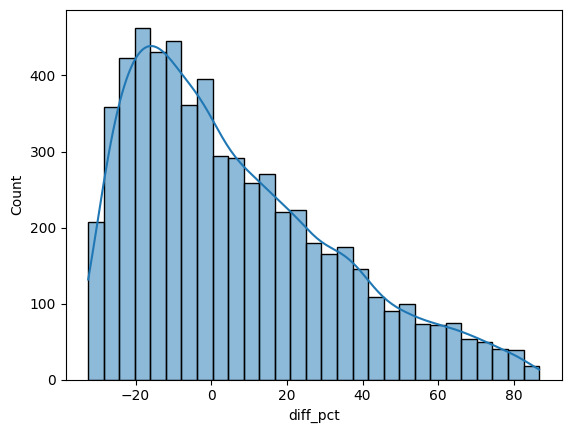

In [110]:
sns.histplot(result_df['diff_pct'],kde=True)

In [111]:
extreme_threshold=10

extreme_result_df=result_df[np.abs(result_df.diff_pct)>extreme_threshold]

extreme_result_df.shape

(4369, 4)

In [112]:
result_df.shape

(6026, 4)

In [113]:
error_margin_pct=extreme_result_df.shape[0]*100/result_df.shape[0]
error_margin_pct

72.50248921340857

In [114]:
result_df[np.abs(result_df.diff_pct)>50].sort_values('diff_pct',ascending=False)

,y_pred,y_test,residuals,diff_pct
12058,6539.415039,3503,3036.415039,86.680418
10165,6515.175781,3501,3014.175781,86.094710
14788,6591.662598,3549,3042.662598,85.732956
13370,6710.313965,3617,3093.313965,85.521536
641,6522.229004,3522,3000.229004,85.185378
...,...,...,...,...
5774,6913.083496,4605,2308.083496,50.121249
8552,6604.676758,4400,2204.676758,50.106290
19486,6520.462891,4344,2176.462891,50.102737
6271,7072.990234,4713,2359.990234,50.074055


In [115]:
x_test.index

Index([10489,  7989,  3113, 10605,  4204, 16419,  6534,  1712, 15712, 10360,
       ...
       12378,  2039,  1023,  8235, 18542, 18960,   266, 10036, 15506, 10890],
      dtype='int64', length=6026)

In [116]:
extreme_result_df.index

Index([10489,  7989,  3113, 10605,  4204, 16419,  6534,  1712, 10360, 18164,
       ...
        6215, 17331, 12378,  1023,  8235, 18542, 18960,   266, 10036, 10890],
      dtype='int64', length=4369)

In [117]:
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10489,0.428571,1.0,0.080808,0.0,0.428571,1,0,0,0,0,0,0,0,0,0,0,0
7989,0.714286,0.0,0.030303,0.0,1.000000,1,0,0,1,1,0,0,0,0,0,0,0
3113,0.142857,0.0,0.363636,0.0,1.000000,1,0,0,1,1,0,0,0,0,1,1,0
10605,0.428571,0.0,0.515152,0.5,0.428571,1,0,1,0,1,0,1,0,0,0,0,0
4204,0.000000,0.0,0.222222,0.0,0.000000,0,0,1,0,1,0,0,1,0,1,0,0


<Axes: xlabel='income_lakhs', ylabel='Count'>

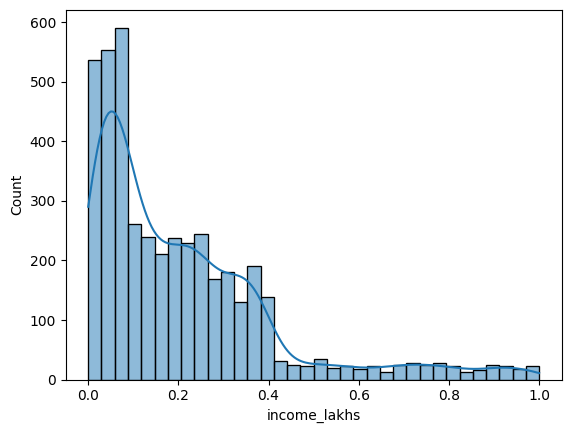

In [118]:
sns.histplot(extreme_error_df.income_lakhs,kde=True)

In [119]:
extreme_col=extreme_error_df.columns


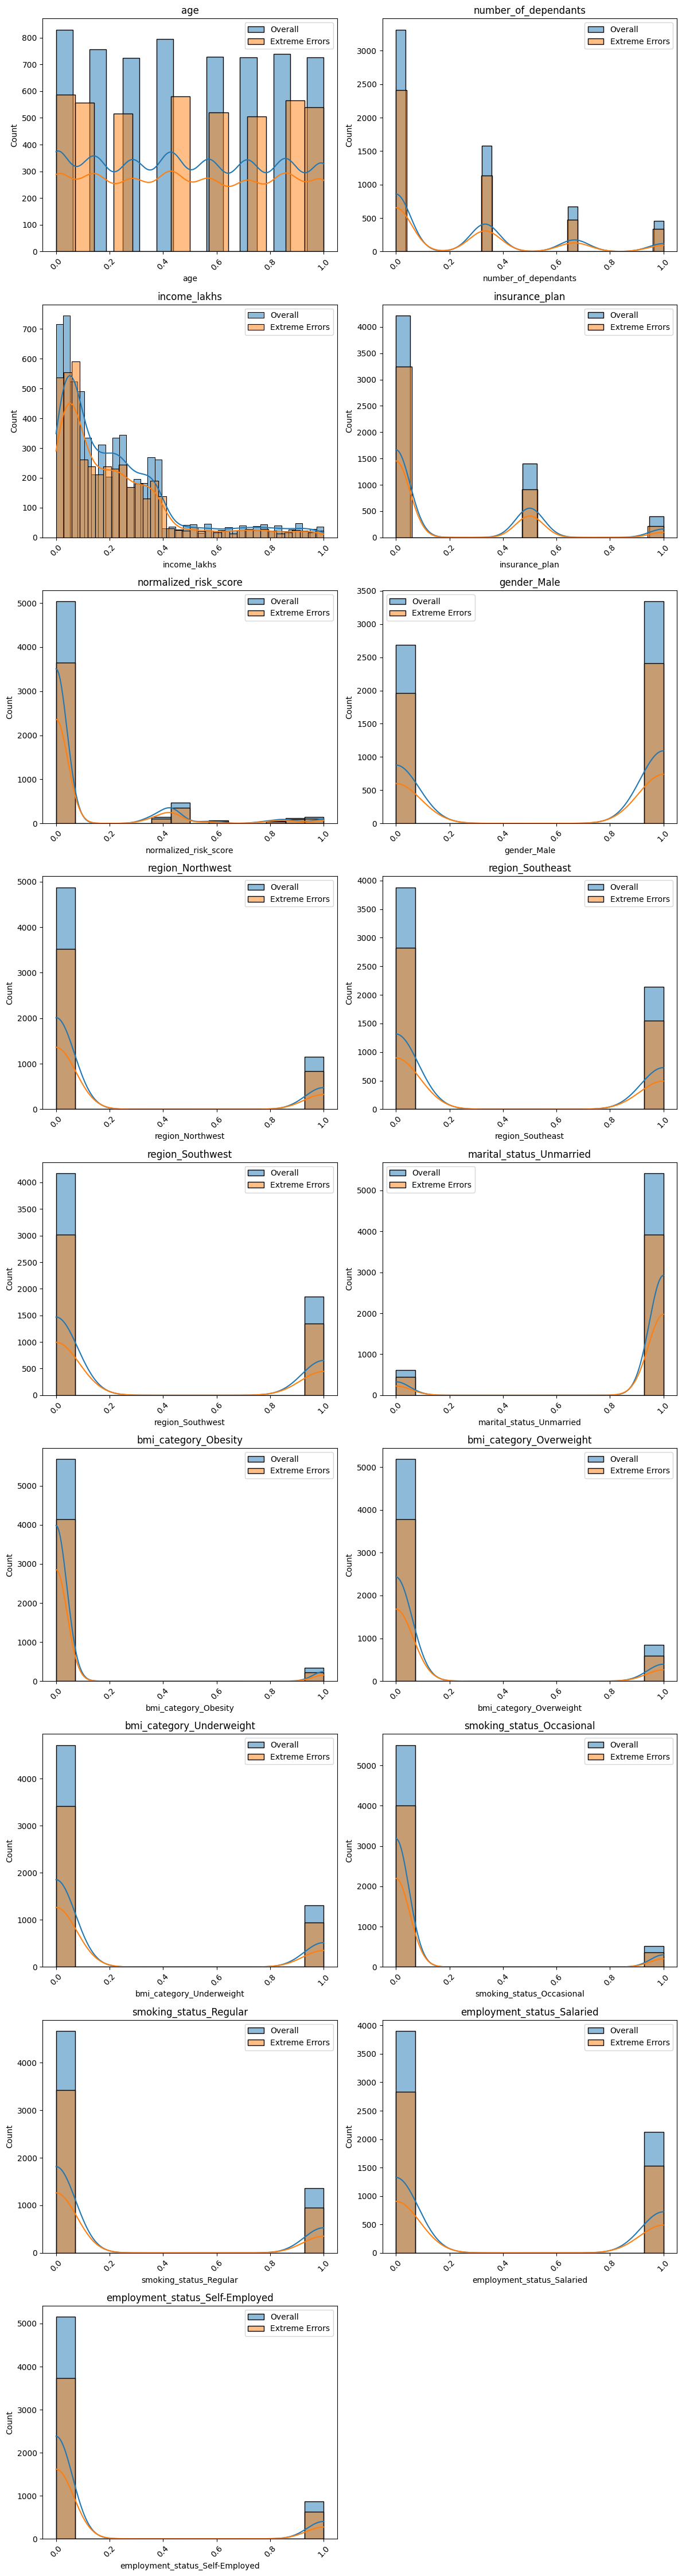

In [120]:
n_cols = 2   # fixed number of columns per row (standard)
n_rows = math.ceil(len(extreme_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, extreme_col):
    sns.histplot(x_test[col],label="Overall",kde=True,ax=ax)
    sns.histplot(extreme_error_df[col],label="Extreme Errors",kde=True,ax=ax) 
    ax.legend()
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(extreme_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.legend()
plt.tight_layout()
plt.show()


## Reverse Transform

- From the visual representation, we can see there are the majority difference in the pattern in age graph.
- 

In [121]:
cols_to_scale

['age', 'number_of_dependants', 'income_lakhs', 'insurance_plan']

<Axes: xlabel='age', ylabel='Count'>

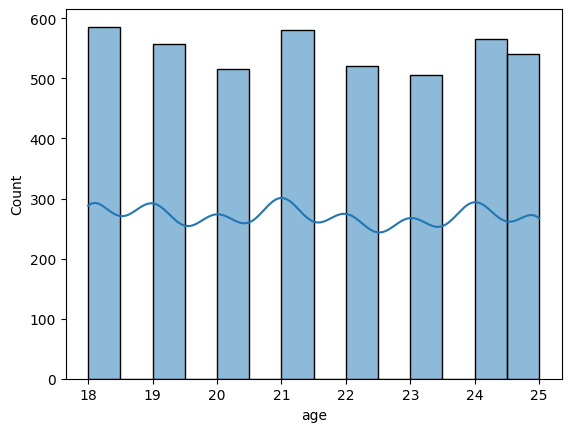

In [122]:
df_reversed=pd.DataFrame()
df_reversed[cols_to_scale]=scaler.inverse_transform(extreme_error_df[cols_to_scale])
sns.histplot(df_reversed['age'],kde=True)

In [123]:
df_reversed['age'].quantile(0.998)

np.float64(25.0)